# LPT Initial Conditions & Conditional HMF — Tier 1 Validation

This notebook validates BEoRN's native LPT initial-conditions engine and the
EPS-based Conditional Halo Mass Function (CHMF).  It is structured as a tutorial
linked from the documentation.

**Sections**
1. [Linear power spectrum](#1.-Linear-power-spectrum)  
2. [σ₈ normalisation check](#2.-σ₈-normalisation-check)  
3. [Initial-conditions density field](#3.-Initial-conditions-density-field)  
4. [1LPT / Zel'dovich displacement](#4.-1LPT-/-Zel'dovich-displacement)  
5. [2LPT displacement and density field](#5.-2LPT-displacement-and-density-field)  
6. [LPT order convergence](#6.-LPT-order-convergence)  
7. [Fixed-amplitude & paired simulations](#7.-Fixed-amplitude-&-paired-simulations)  
8. [Validation against 21cmFAST LPT fields](#8.-Validation-against-21cmFAST-LPT-fields)  
9. [Velocity field validation](#9.-Velocity-field-validation)  
10. [EPS Conditional HMF](#10.-EPS-Conditional-HMF)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.integrate import quad

import beorn
from beorn.structs import Parameters
from beorn import lpt
from beorn.cosmo import D

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
print('beorn version:', beorn.__version__ if hasattr(beorn, '__version__') else 'dev')

beorn version: dev


In [2]:
# Fiducial cosmology — matches Planck 2018 TT,TE,EE+lowE best-fit
param = Parameters()
param.simulation.Ncell = 128    # 128³ grid — fast enough for development
param.simulation.Lbox  = 100   # 100 Mpc/h

cosmo = param.cosmology
print(f'Ωm={cosmo.Om}  Ωb={cosmo.Ob}  h={cosmo.h0}  σ₈={cosmo.sigma_8}  ns={cosmo.ns}')

Ωm=0.315  Ωb=0.045  h=0.673  σ₈=0.83  ns=0.96


---
## 1. Linear power spectrum

Compare Eisenstein & Hu (1998) no-wiggle and wiggle fits at z = 0 and z = 10.

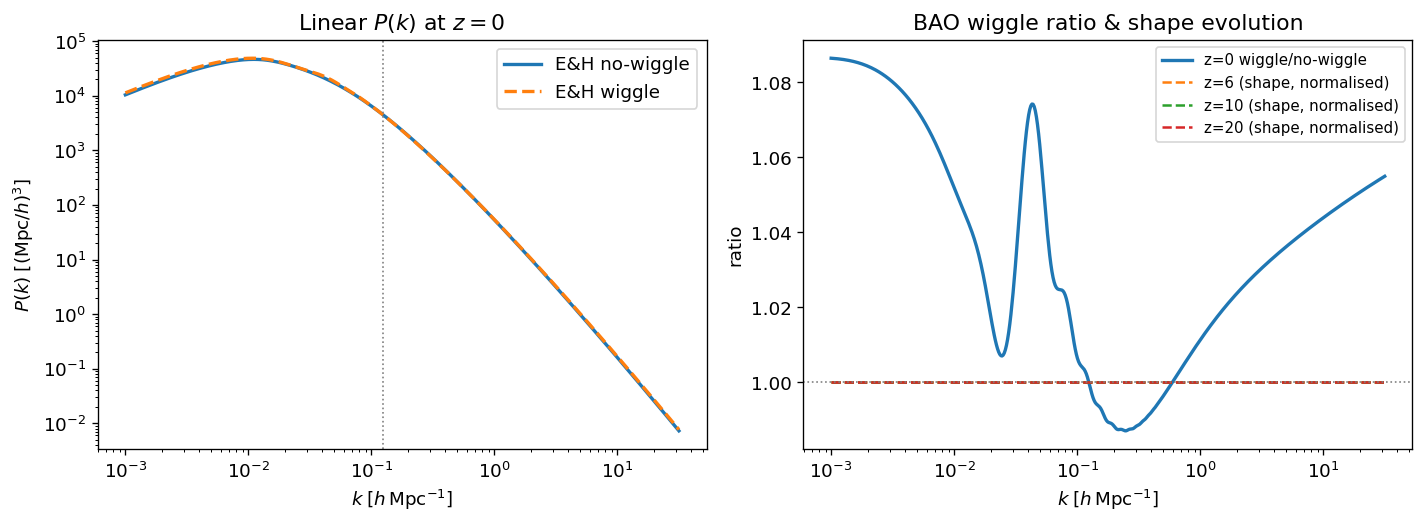

In [3]:
k = np.logspace(-3, 1.5, 500)   # h/Mpc

eh_nw = lpt.EisensteinHu(param, wiggle=False)
eh_w  = lpt.EisensteinHu(param, wiggle=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# --- P(k) at z=0 ---
ax = axes[0]
ax.loglog(k, eh_nw.P(k, z=0), label='E&H no-wiggle', lw=2)
ax.loglog(k, eh_w.P(k,  z=0), label='E&H wiggle',    lw=2, ls='--')
ax.set_xlabel(r'$k\;[h\,\mathrm{Mpc}^{-1}]$')
ax.set_ylabel(r'$P(k)\;[(\mathrm{Mpc}/h)^3]$')
ax.set_title('Linear $P(k)$ at $z=0$')
ax.legend()
ax.axvline(1/8, ls=':', color='grey', lw=1, label=r'$k=1/(8\,h^{-1}\mathrm{Mpc})$')

# --- ratio and redshift evolution ---
ax = axes[1]
ax.semilogx(k, eh_w.P(k, z=0) / eh_nw.P(k, z=0), label='z=0 wiggle/no-wiggle', lw=2)
for z in [6, 10, 20]:
    ratio = eh_w.P(k, z=z) / eh_w.P(k, z=0)
    ax.semilogx(k, ratio / ratio.mean(), ls='--', label=f'z={z} (shape, normalised)')
ax.axhline(1, ls=':', color='grey', lw=1)
ax.set_xlabel(r'$k\;[h\,\mathrm{Mpc}^{-1}]$')
ax.set_ylabel('ratio')
ax.set_title('BAO wiggle ratio & shape evolution')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

---
## 2. σ₈ normalisation check

Integrate $P(k)$ against the real-space top-hat window of radius $8\,h^{-1}\mathrm{Mpc}$ and verify we recover the input $\sigma_8$.

σ₈ (no-wiggle) = 0.82893   target = 0.83
σ₈ (wiggle) = 0.82999   target = 0.83


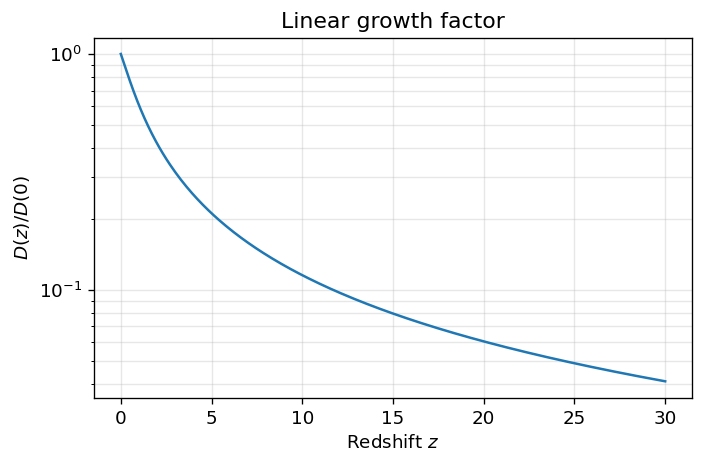

In [4]:
def sigma_r(ps, R, z=0):
    """rms density fluctuation in spheres of radius R (Mpc/h)."""
    def integrand(lnk):
        k_ = np.exp(lnk)
        x  = k_ * R
        W  = 3 * (np.sin(x) - x * np.cos(x)) / x**3
        return k_**3 * ps.P(k_, z=z) * W**2 / (2 * np.pi**2)
    result, _ = quad(integrand, np.log(1e-4), np.log(1e3), limit=300)
    return np.sqrt(result)

for label, ps in [('no-wiggle', eh_nw), ('wiggle', eh_w)]:
    s8 = sigma_r(ps, R=8, z=0)
    print(f'σ₈ ({label}) = {s8:.5f}   target = {cosmo.sigma_8}')

# Growth factor vs redshift
zz = np.linspace(0, 30, 300)
aa = 1 / (1 + zz)
Dz = np.array([D(a, param) / D(1.0, param) for a in aa])

fig, ax = plt.subplots(figsize=(6, 4))
ax.semilogy(zz, Dz)
ax.set_xlabel('Redshift $z$')
ax.set_ylabel(r'$D(z)/D(0)$')
ax.set_title('Linear growth factor')
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

---
## 3. Initial-conditions density field

Draw a Gaussian realisation from $P(k)$ and compute its power spectrum.  
The measured $P(k)$ should match the input (modulo shot noise and aliasing).

In [5]:
SEED = 42
za = lpt.ZeldovichApproximation(param, seed=SEED)
delta_k_ic = za.delta_k          # shape (N, N, N//2+1)
N = param.simulation.Ncell
L = param.simulation.Lbox
delta_ic   = np.fft.irfftn(delta_k_ic, s=(N, N, N))

print(f'δ IC:  mean={delta_ic.mean():.3e}  std={delta_ic.std():.4f}')
print(f'Grid: {N}³  Lbox={L} Mpc/h')

[BEoRN LPT] backend → TorchBackend  (device=mps, float32)
δ IC:  mean=-5.584e-18  std=3.1492
Grid: 128³  Lbox=100 Mpc/h


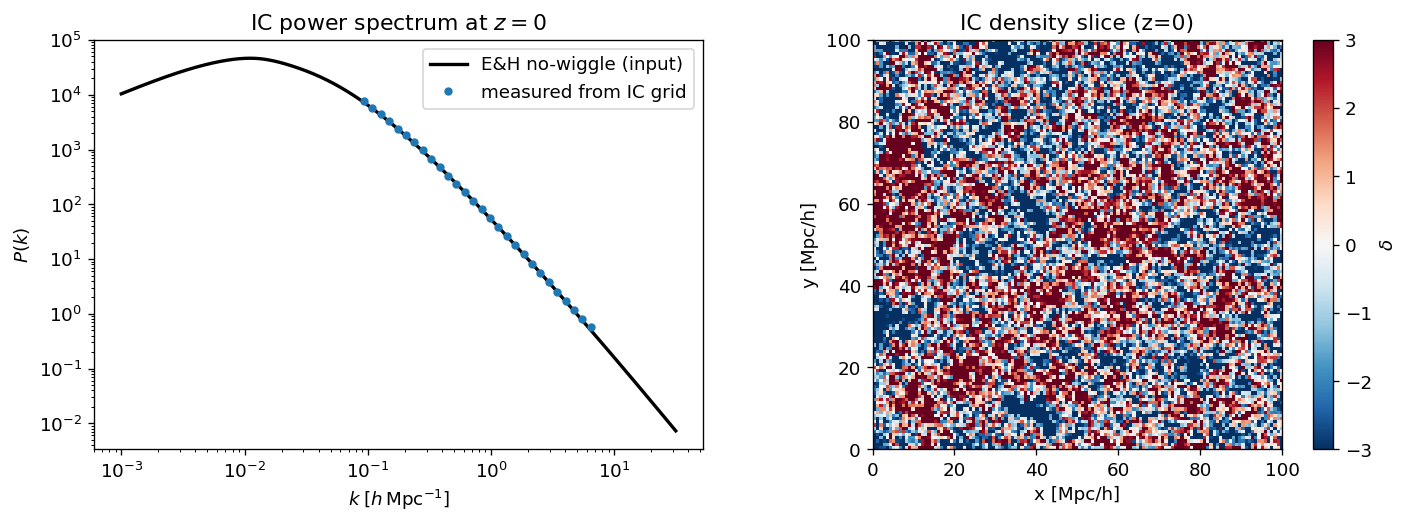

In [6]:
import tools21cm as t2c

# Convenience alias: returns (Pk, k_bins) matching the call pattern used below.
# box_dims in Mpc/h → k_bins in h/Mpc.
def ps1d(delta, Lbox, kbins=30):
    Pk, k = t2c.power_spectrum.power_spectrum_1d(delta, box_dims=Lbox, kbins=kbins)
    return k, Pk

k_meas, Pk_meas = ps1d(delta_ic, param.simulation.Lbox)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
ax.loglog(k, eh_nw.P(k, z=0), 'k-', lw=2, label='E&H no-wiggle (input)')
ax.loglog(k_meas, Pk_meas, 'o', ms=4, label='measured from IC grid')
ax.set_xlabel(r'$k\;[h\,\mathrm{Mpc}^{-1}]$')
ax.set_ylabel(r'$P(k)$')
ax.set_title('IC power spectrum at $z=0$')
ax.legend()

ax = axes[1]
ax.imshow(delta_ic[:, :, param.simulation.Ncell//2],
          origin='lower', cmap='RdBu_r',
          extent=[0, param.simulation.Lbox]*2, vmin=-3, vmax=3)
ax.set_xlabel('x [Mpc/h]')
ax.set_ylabel('y [Mpc/h]')
ax.set_title('IC density slice (z=0)')
plt.colorbar(ax.images[0], ax=ax, label=r'$\delta$')

plt.tight_layout()
plt.show()

---
## 4. 1LPT / Zel'dovich displacement

The Zel'dovich displacement $\Psi^{(1)}$ moves particles from their Lagrangian positions $\mathbf{q}$ to Eulerian positions $\mathbf{x} = \mathbf{q} + D_1(z)\,\Psi^{(1)}(\mathbf{q})$.

z = 10.0   D₁(z)/D(0) = 0.11536
Ψx rms = 0.530 Mpc/h  Ψy rms = 0.530 Mpc/h  Ψz rms = 0.530 Mpc/h


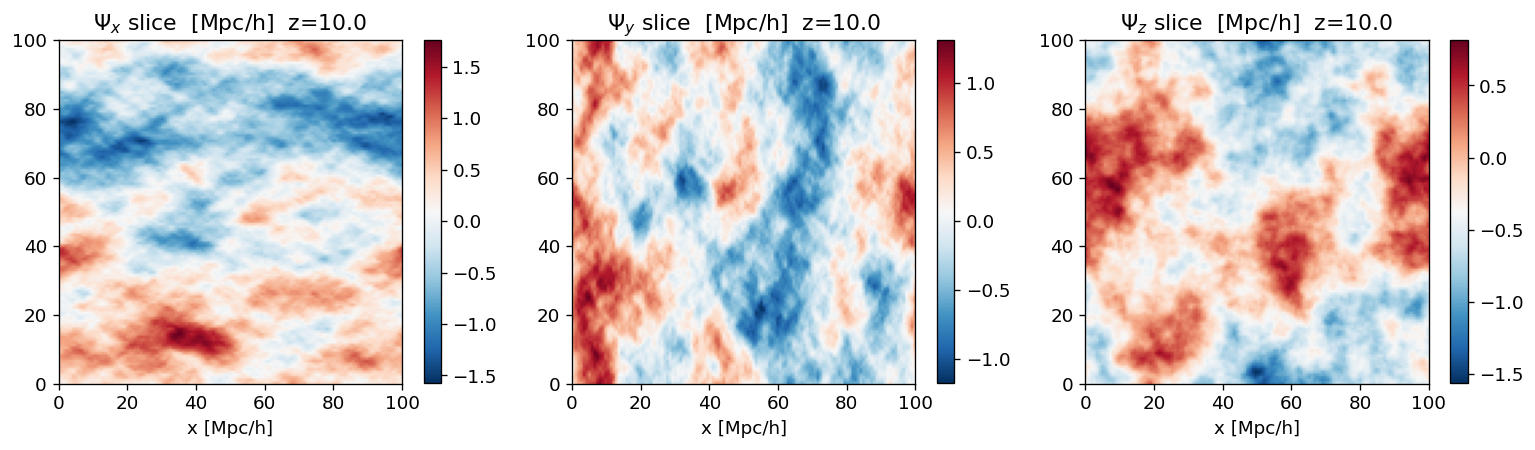

In [7]:
z_target = 10.0 #0.01 #

psi_x, psi_y, psi_z = za.get_displacement(z=z_target)
a_t = 1 / (1 + z_target)
D1  = D(a_t, param) / D(1.0, param)

print(f'z = {z_target}   D₁(z)/D(0) = {D1:.5f}')
print(f'Ψx rms = {psi_x.std():.3f} Mpc/h  '
      f'Ψy rms = {psi_y.std():.3f} Mpc/h  '
      f'Ψz rms = {psi_z.std():.3f} Mpc/h')

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
sl = param.simulation.Ncell // 2
L  = param.simulation.Lbox
for ax, field, label in zip(axes,
                             [psi_x, psi_y, psi_z],
                             [r'$\Psi_x$', r'$\Psi_y$', r'$\Psi_z$']):
    im = ax.imshow(field[:, :, sl], origin='lower', cmap='RdBu_r',
                   extent=[0, L, 0, L])
    ax.set_title(f'{label} slice  [Mpc/h]  z={z_target}')
    ax.set_xlabel('x [Mpc/h]')
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
plt.show()

ZA density:  mean=-2.372e-07  std=0.3079


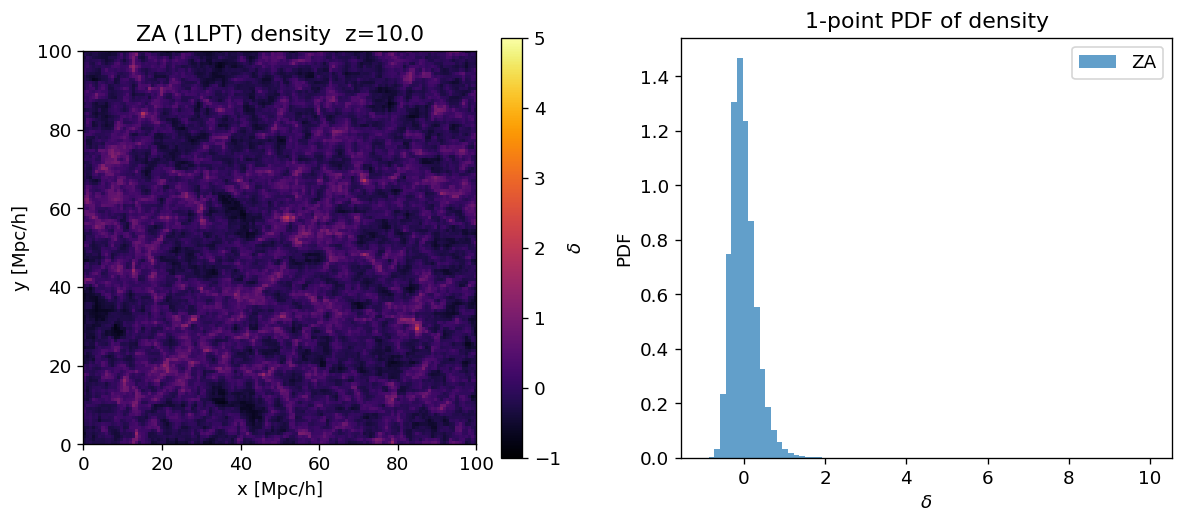

In [8]:
# 1LPT density field
delta_za = za.get_density(z=z_target)
print(f'ZA density:  mean={delta_za.mean():.3e}  std={delta_za.std():.4f}')

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

ax = axes[0]
im = ax.imshow(delta_za[:, :, sl], origin='lower', cmap='inferno',
               extent=[0, L, 0, L], vmin=-1, vmax=5)
ax.set_title(f'ZA (1LPT) density  z={z_target}')
ax.set_xlabel('x [Mpc/h]')
ax.set_ylabel('y [Mpc/h]')
plt.colorbar(im, ax=ax, label=r'$\delta$')

ax = axes[1]
bins = np.linspace(-1, 10, 80)
ax.hist(delta_za.ravel(), bins=bins, density=True, alpha=0.7, label='ZA')
ax.set_xlabel(r'$\delta$')
ax.set_ylabel('PDF')
ax.set_title('1-point PDF of density')
ax.legend()

plt.tight_layout()
plt.show()

---
## 5. 2LPT displacement and density field

2LPT adds a second-order correction driven by
$$\Delta^{(2)} = \sum_{i<j}\left[\varphi^{(1)}_{,ii}\,\varphi^{(1)}_{,jj} - \left(\varphi^{(1)}_{,ij}\right)^2\right]$$
with growth factor $D_2(z) \approx -\tfrac{3}{7}D_1^2(z)$.

In [9]:
lpt2 = lpt.SecondOrderLPT(param, seed=SEED)   # same seed → same δ(k)

psi2_x, psi2_y, psi2_z = lpt2.get_displacement(z=z_target)
delta_2lpt = lpt2.get_density(z=z_target)

D2 = -3/7 * D1**2
print(f'D₂/D₁ = {D2/D1:.5f}')
print(f'2LPT Ψx rms = {psi2_x.std():.3f} Mpc/h   '
      f'ZA  Ψx rms = {psi_x.std():.3f} Mpc/h')

[BEoRN LPT] backend → TorchBackend  (device=mps, float32)
D₂/D₁ = -0.04944
2LPT Ψx rms = 0.530 Mpc/h   ZA  Ψx rms = 0.530 Mpc/h


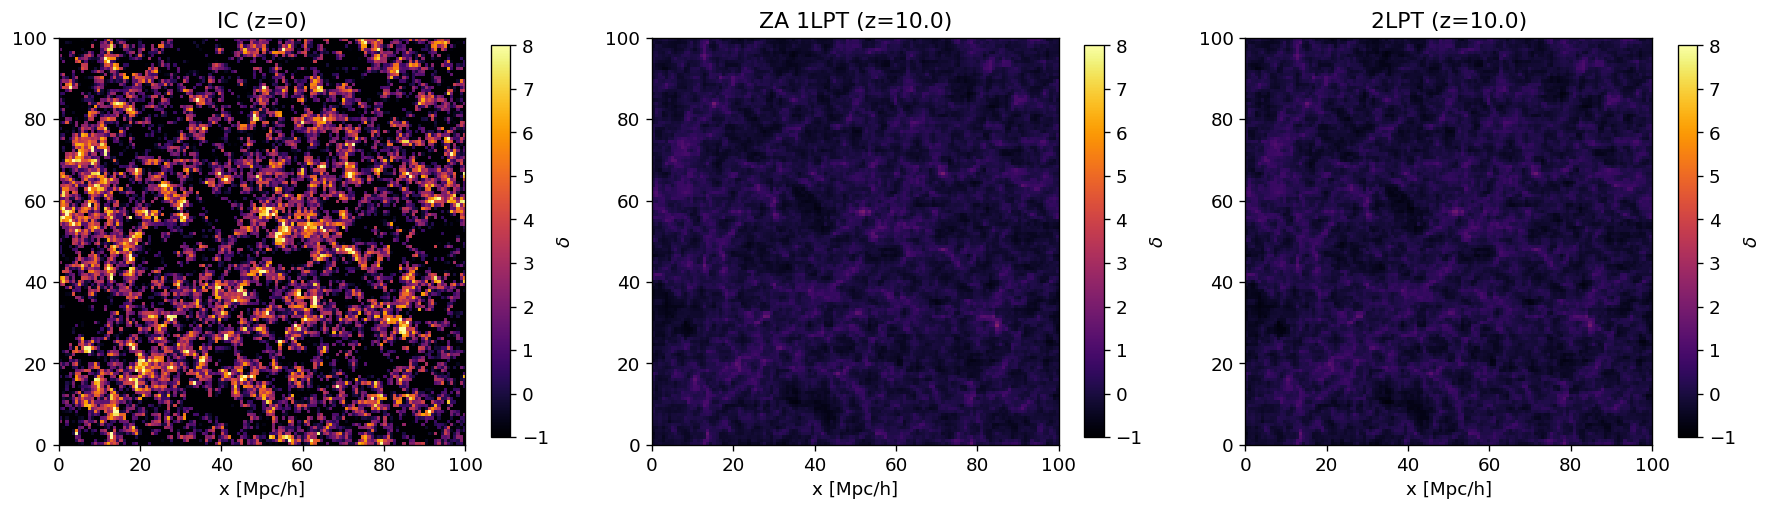

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

vmin, vmax = -1, 8
for ax, field, title in zip(axes,
    [delta_ic[:,:,sl], delta_za[:,:,sl], delta_2lpt[:,:,sl]],
    ['IC (z=0)', f'ZA 1LPT (z={z_target})', f'2LPT (z={z_target})']):
    im = ax.imshow(field, origin='lower', cmap='inferno',
                   extent=[0, L, 0, L], vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.set_xlabel('x [Mpc/h]')
    plt.colorbar(im, ax=ax, label=r'$\delta$', shrink=0.8)

plt.tight_layout()
plt.show()

Shot noise floor: P_shot = (L/N)³ = 0.477 (Mpc/h)³
Linear P(k=1 h/Mpc, z=10.0) = 0.710 (Mpc/h)³


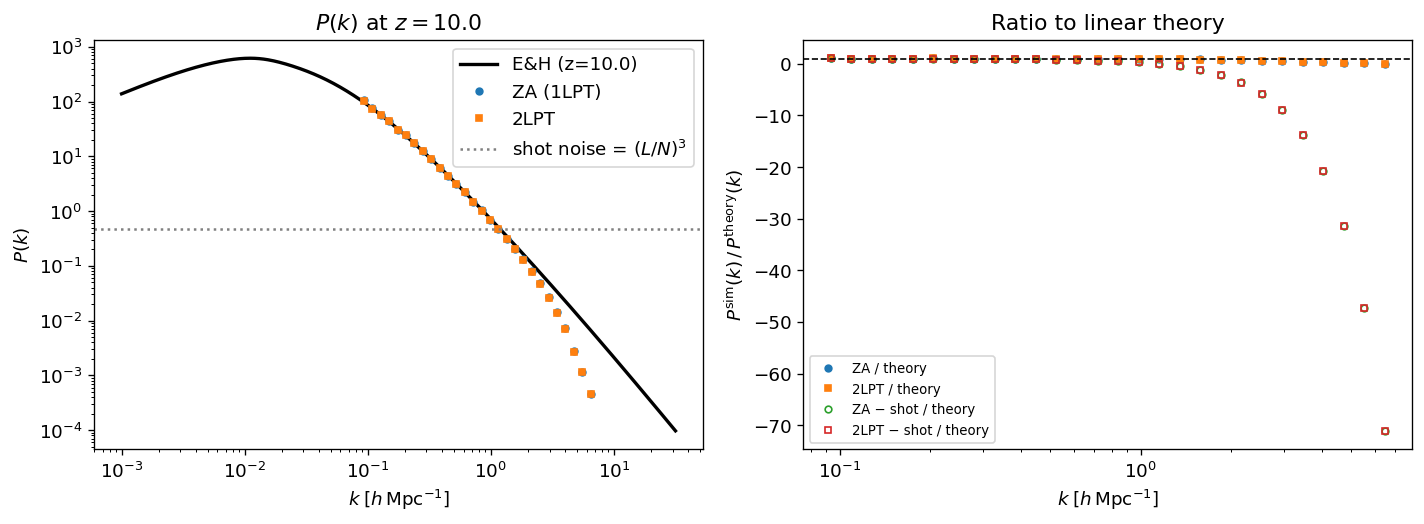

In [11]:
# Power spectra: ZA vs 2LPT vs theory
k_za,   Pk_za   = ps1d(delta_za,   L)
k_2lpt, Pk_2lpt = ps1d(delta_2lpt, L)
Pk_theory = eh_nw.P(k, z=z_target)

# Shot noise from discrete CIC particles: P_shot = (L/N)³ (Mpc/h)³
P_shot = (L / N)**3
print(f'Shot noise floor: P_shot = (L/N)³ = {P_shot:.3f} (Mpc/h)³')
print(f'Linear P(k=1 h/Mpc, z={z_target}) = {eh_nw.P(np.array([1.0]), z=z_target)[0]:.3f} (Mpc/h)³')

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
ax.loglog(k,       Pk_theory,           'k-',  lw=2,  label=f'E&H (z={z_target})')
ax.loglog(k_za,    Pk_za,               'o',   ms=4,  label='ZA (1LPT)')
ax.loglog(k_2lpt,  Pk_2lpt,             's',   ms=4,  label='2LPT')
ax.axhline(P_shot, ls=':', color='grey', lw=1.5, label=f'shot noise = $(L/N)^3$')
ax.set_xlabel(r'$k\;[h\,\mathrm{Mpc}^{-1}]$')
ax.set_ylabel(r'$P(k)$')
ax.set_title(f'$P(k)$ at $z={z_target}$')
ax.legend()

ax = axes[1]
ax.semilogx(k_za,   Pk_za   / np.interp(k_za,   k, Pk_theory), 'o', ms=4, label='ZA / theory')
ax.semilogx(k_2lpt, Pk_2lpt / np.interp(k_2lpt, k, Pk_theory), 's', ms=4, label='2LPT / theory')
ax.semilogx(k_za,   (Pk_za   - P_shot) / np.interp(k_za,   k, Pk_theory),
            'o', ms=4, mfc='none', label='ZA − shot / theory')
ax.semilogx(k_2lpt, (Pk_2lpt - P_shot) / np.interp(k_2lpt, k, Pk_theory),
            's', ms=4, mfc='none', label='2LPT − shot / theory')
ax.axhline(1, ls='--', color='k', lw=1)
ax.set_xlabel(r'$k\;[h\,\mathrm{Mpc}^{-1}]$')
ax.set_ylabel(r'$P^\mathrm{sim}(k)\,/\,P^\mathrm{theory}(k)$')
ax.set_title('Ratio to linear theory')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

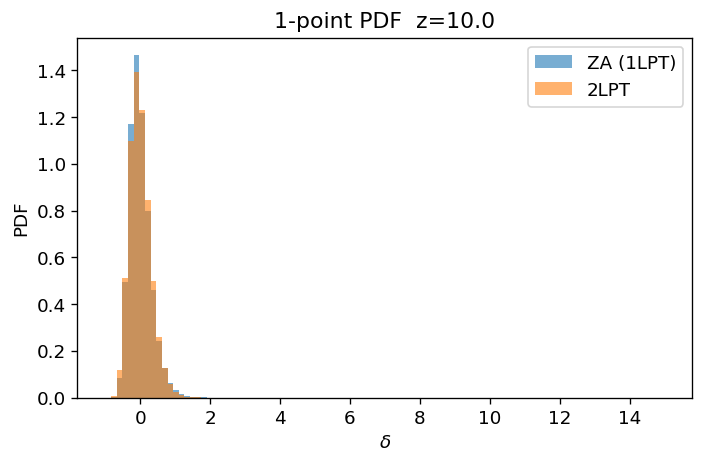

In [12]:
# 1-point PDF comparison
bins = np.linspace(-1, 15, 100)
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(delta_za.ravel(),   bins=bins, density=True, alpha=0.6, label='ZA (1LPT)')
ax.hist(delta_2lpt.ravel(), bins=bins, density=True, alpha=0.6, label='2LPT')
ax.set_xlabel(r'$\delta$')
ax.set_ylabel('PDF')
ax.set_title(f'1-point PDF  z={z_target}')
ax.legend()
plt.tight_layout()
plt.show()

---
## 6. LPT order convergence

The LPT expansion converges when $D_1(z)\,|\nabla\Psi^{(1)}| \ll 1$.  
We check convergence by comparing displacement rms across orders at several redshifts.  
At low redshift the hierarchy diverges — this is expected and motivates using 2LPT at high $z$.

[BEoRN LPT] backend → TorchBackend  (device=mps, float32)
[BEoRN LPT] backend → TorchBackend  (device=mps, float32)
[BEoRN LPT] backend → TorchBackend  (device=mps, float32)


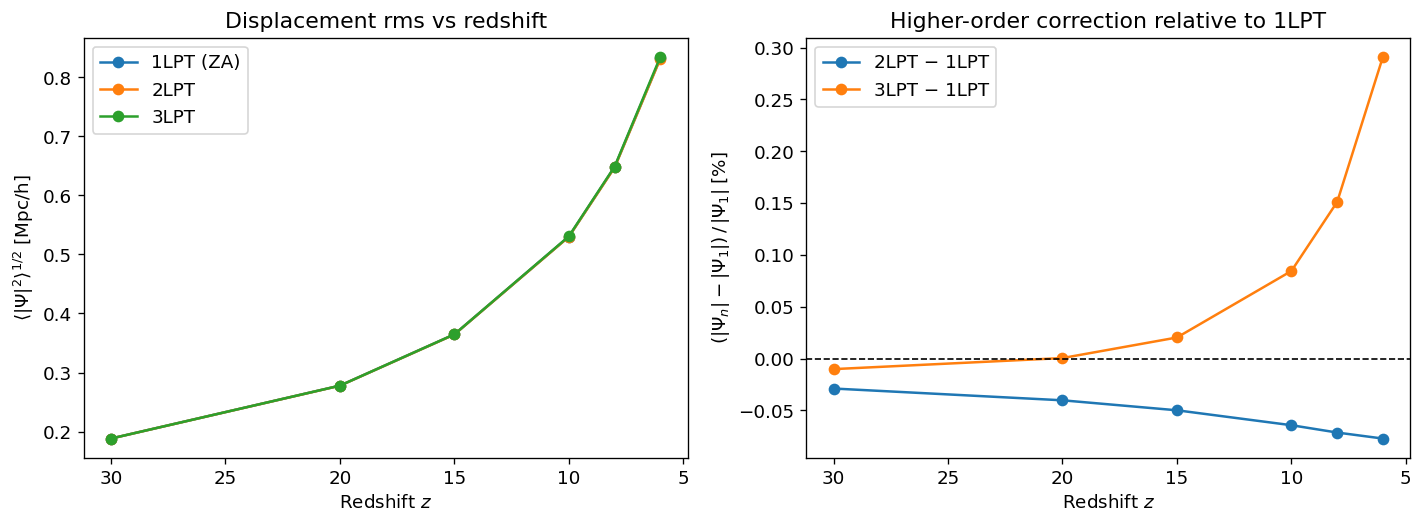

In [13]:
redshifts = [30, 20, 15, 10, 8, 6]
solvers = {
    '1LPT (ZA)': lpt.ZeldovichApproximation(param, seed=SEED),
    '2LPT':      lpt.SecondOrderLPT(param, seed=SEED),
    '3LPT':      lpt.ThirdOrderLPT(param, seed=SEED),
}

results = {name: [] for name in solvers}
for z in redshifts:
    for name, solver in solvers.items():
        psi = solver.get_displacement(z)
        rms = np.sqrt(np.mean([c**2 for c in psi]))
        results[name].append(rms)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
for name, vals in results.items():
    ax.plot(redshifts, vals, 'o-', label=name)
ax.set_xlabel('Redshift $z$')
ax.set_ylabel(r'$\langle|\Psi|^2\rangle^{1/2}$ [Mpc/h]')
ax.set_title('Displacement rms vs redshift')
ax.legend()
ax.invert_xaxis()

ax = axes[1]
rms_1lpt = np.array(results['1LPT (ZA)'])
for name, vals in results.items():
    if name == '1LPT (ZA)':
        continue
    ratio = (np.array(vals) - rms_1lpt) / rms_1lpt * 100
    ax.plot(redshifts, ratio, 'o-', label=f'{name} − 1LPT')
ax.axhline(0, ls='--', color='k', lw=1)
ax.set_xlabel('Redshift $z$')
ax.set_ylabel(r'$(|\Psi_n| - |\Psi_1|)\,/\,|\Psi_1|\;[\%]$')
ax.set_title('Higher-order correction relative to 1LPT')
ax.legend()
ax.invert_xaxis()

plt.tight_layout()
plt.show()

In [14]:
# Growth factor ratios: confirm that higher-order corrections shrink at high z
print('z     D₁        D₂/D₁     D₃ₐ/D₁²')
print('-'*45)
for z in redshifts:
    a  = 1/(1+z)
    D1 = D(a, param) / D(1.0, param)
    D2 = -3/7 * D1**2
    D3a = 1/3 * D1**3
    print(f'{z:4d}  {D1:.5f}   {D2/D1:+.5f}   {D3a/D1**2:+.5f}')

z     D₁        D₂/D₁     D₃ₐ/D₁²
---------------------------------------------
  30  0.04094   -0.01755   +0.01365
  20  0.06044   -0.02590   +0.02015
  15  0.07933   -0.03400   +0.02644
  10  0.11536   -0.04944   +0.03845
   8  0.14097   -0.06041   +0.04699
   6  0.18113   -0.07763   +0.06038


---
## 7. Fixed-amplitude & paired simulations

**Fixed-amplitude ICs** (Angulo & Pontzen 2016): every k-mode amplitude is
pinned to exactly $\sqrt{P(k)\,V/N^3}$, only the random phases are drawn from
the noise realisation.  This eliminates Rayleigh mode scatter and strongly
reduces cosmic variance.

**Paired simulations** use seed $-s$ to negate the entire noise field, flipping
all phases by $\pi$, so $\delta_-(k) = -\delta_+(k)$ exactly.  Key properties:

- $\delta_-(\mathbf{x}) = -\delta_+(\mathbf{x})$ at the linear IC level → pixel correlation $r = -1.000$.  
- Both runs share the same $P(k)$ — they bracket the ensemble mean.  
- Their average $(\delta_+ + \delta_-)/2 \approx 0$ with strongly suppressed variance.

In [15]:
N = param.simulation.Ncell

# Positive seed (standard run) and its paired counterpart
za_pos = lpt.ZeldovichApproximation(param, seed=42,  verbose=False)
za_neg = lpt.ZeldovichApproximation(param, seed=-42, verbose=False)

# Linear IC fields at z = 0 (before displacement)
delta_ic_pos = np.fft.irfftn(za_pos.delta_k, s=(N, N, N))
delta_ic_neg = np.fft.irfftn(za_neg.delta_k, s=(N, N, N))

r_ic = np.corrcoef(delta_ic_pos.ravel(), delta_ic_neg.ravel())[0, 1]
print(f'IC pixel correlation r  = {r_ic:.6f}   (expect -1.000 for fixed=True)')
print(f'IC std(δ+)  = {delta_ic_pos.std():.4f}   std(δ−) = {delta_ic_neg.std():.4f}')
print(f'IC std(avg) = {((delta_ic_pos + delta_ic_neg) / 2).std():.6f}   (expect ≈ 0)')

# Displaced density fields (CIC introduces weak nonlinearity → r is not exactly -1)
delta_pos = za_pos.get_density(z=z_target)
delta_neg = za_neg.get_density(z=z_target)

r_disp = np.corrcoef(delta_pos.ravel(), delta_neg.ravel())[0, 1]
print(f'\nDisplaced density (z={z_target}):')
print(f'  pixel correlation r = {r_disp:.4f}')
print(f'  std(δ+)  = {delta_pos.std():.4f}   std(δ−) = {delta_neg.std():.4f}')
print(f'  std(avg) = {((delta_pos + delta_neg) / 2).std():.4f}')

IC pixel correlation r  = -1.000000   (expect -1.000 for fixed=True)
IC std(δ+)  = 3.1492   std(δ−) = 3.1492
IC std(avg) = 0.000000   (expect ≈ 0)

Displaced density (z=10.0):
  pixel correlation r = -0.4480
  std(δ+)  = 0.3079   std(δ−) = 0.3077
  std(avg) = 0.1617


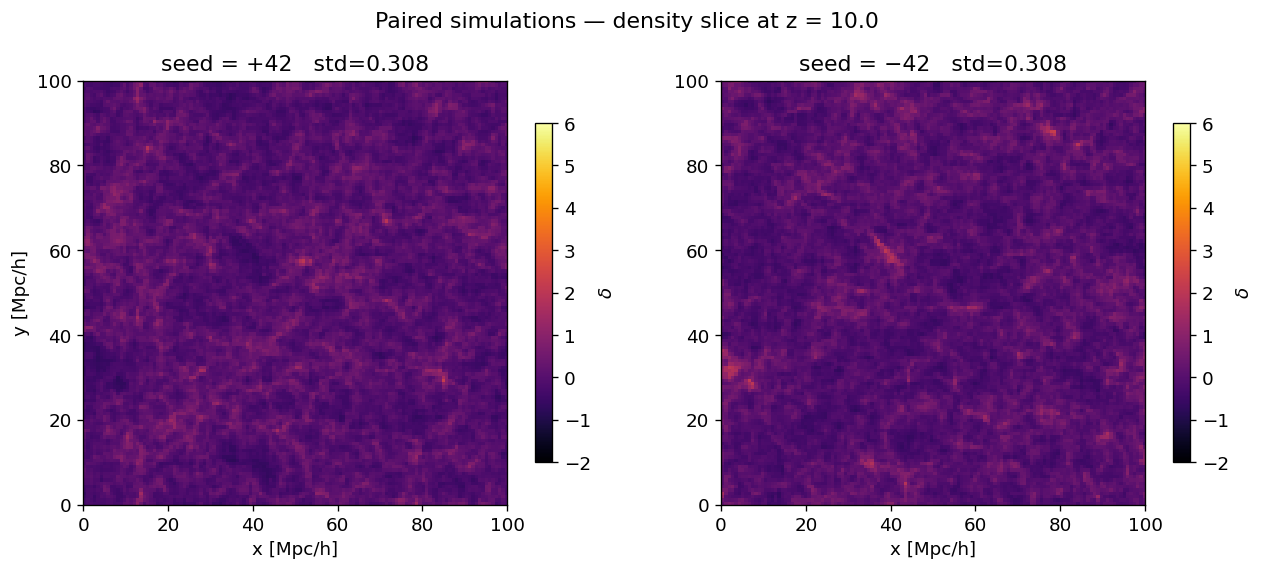

In [16]:
# Density slices for paired simulations (seed +42 vs seed −42)
sl = N // 2

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
vmin, vmax = -2, 6

for ax, field, title in zip(
    axes,
    [delta_pos[:, :, sl], delta_neg[:, :, sl]],
    [f'seed = +42   std={delta_pos.std():.3f}',
     f'seed = −42   std={delta_neg.std():.3f}'],
):
    im = ax.imshow(field, origin='lower', cmap='inferno',
                   extent=[0, L, 0, L], vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.set_xlabel('x [Mpc/h]')
    plt.colorbar(im, ax=ax, label=r'$\delta$', shrink=0.8)

axes[0].set_ylabel('y [Mpc/h]')
fig.suptitle(f'Paired simulations — density slice at z = {z_target}', y=1.01)
plt.tight_layout()
plt.show()

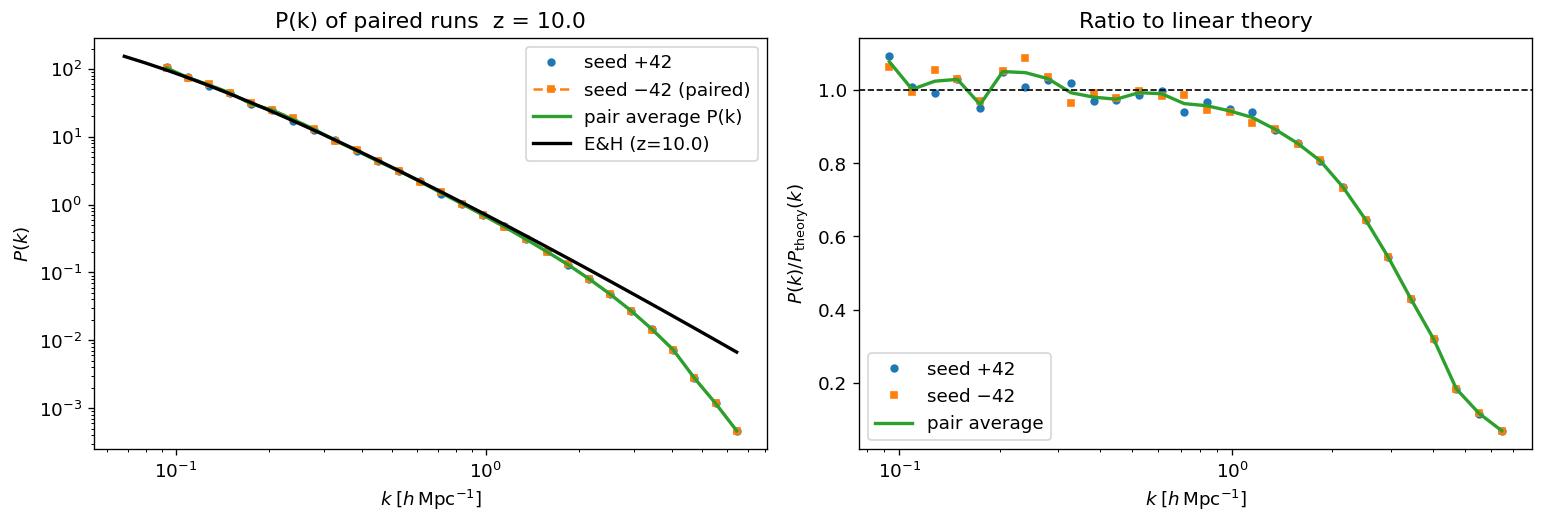

P(k) rms scatter (seed +42 vs −42): nan % of theory


In [17]:
# Power spectra of paired simulations
# Average of P(k)s — not of the density fields themselves — is the correct estimator
k_pos, Pk_pos = ps1d(delta_pos, L)
k_neg, Pk_neg = ps1d(delta_neg, L)
Pk_avg = (Pk_pos + Pk_neg) / 2          # average over the pair
Pk_th  = eh_nw.P(k_pos, z=z_target)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
ax.loglog(k_pos, Pk_pos,  'C0o', ms=4, label='seed +42')
ax.loglog(k_neg, Pk_neg,  'C1s', ms=4, label='seed −42 (paired)', ls='--')
ax.loglog(k_pos, Pk_avg,  'C2-', lw=2, label='pair average P(k)')
ax.loglog(k_pos, Pk_th,   'k-',  lw=2, label=f'E&H (z={z_target})')
ax.set_xlabel(r'$k\;[h\,\mathrm{Mpc}^{-1}]$')
ax.set_ylabel(r'$P(k)$')
ax.set_title(f'P(k) of paired runs  z = {z_target}')
ax.legend()

ax = axes[1]
ax.semilogx(k_pos, Pk_pos / Pk_th, 'C0o', ms=4, label='seed +42')
ax.semilogx(k_neg, Pk_neg / Pk_th, 'C1s', ms=4, label='seed −42')
ax.semilogx(k_pos, Pk_avg / Pk_th, 'C2-', lw=2, label='pair average')
ax.axhline(1, ls='--', color='k', lw=1)
ax.set_xlabel(r'$k\;[h\,\mathrm{Mpc}^{-1}]$')
ax.set_ylabel(r'$P(k) / P_\mathrm{theory}(k)$')
ax.set_title('Ratio to linear theory')
ax.legend()

plt.tight_layout()
plt.show()

print(f'P(k) rms scatter (seed +42 vs −42): '
      f'{np.std((Pk_pos - Pk_neg) / Pk_th * 100):.1f} % of theory')

---
## 8. Validation against 21cmFAST LPT fields

**Goal:** compare BEoRN's ZA density field against the field produced by
`py21cmfast` with the same cosmology, box size, and random seed, and show
how to feed a 21cmFAST GRF directly into BEoRN for a structure-by-structure
comparison.

### Strategy

21cmFAST and BEoRN both implement the Zel'dovich approximation but generate
their Gaussian random field (GRF) using different random-number libraries
(GSL in C vs NumPy).  Two comparison modes are therefore available:

| Mode | What it tests | Seeding |
|---|---|---|
| **Statistical** | P(k), PDF agree to < 5 % | Any matching seed (RNG-agnostic) |
| **Pixel-level** | δ(x) field matches at every cell | Inject 21cmFAST GRF via `grf=` parameter |

### GRF injection

`py21cmfast.InitialConditions.lowres_density` stores the linear overdensity
field δ at the `HII_DIM` grid, normalised at z = 0.  Feeding its Fourier
transform directly to BEoRN bypasses BEoRN's own RNG and P(k) normalisation:

```python
delta_k_21cm = np.fft.rfftn(IC.lowres_density)  # shape (N, N, N//2+1)
za_21cm = lpt.ZeldovichApproximation(param, verbose=False)
za_21cm.generate_initial_conditions(grf=delta_k_21cm)
delta_beorn = za_21cm.get_density(z=z_target)
```

Both codes then solve the same ZA problem from the same δ(k) starting point,
so the resulting density fields should agree at the few-percent level.

In [18]:
try:
    import py21cmfast as p21c
    _p21cm_available = True
    print(f'py21cmfast {p21c.__version__} found.')
except ImportError:
    _p21cm_available = False
    print('py21cmfast not installed — install with: pip install py21cmfast')
    print('Cells below show the full comparison code; outputs require py21cmfast.')

# ── py21cmfast setup (mirrors the BEoRN param object) ─────────────────────────
if _p21cm_available:
    cosmo = param.cosmology
    N21   = param.simulation.Ncell
    L21   = param.simulation.Lbox / cosmo.h0   # py21cmfast uses Mpc, not Mpc/h

    user_params = p21c.UserParams(
        HII_DIM=N21,
        DIM=N21 * 3,          # high-res internal grid
        BOX_LEN=L21,
        N_THREADS=4,
    )
    cosmo_params = p21c.CosmoParams(
        SIGMA_8=cosmo.sigma_8,
        hlittle=cosmo.h0,
        OMm=cosmo.Om,
        OMb=cosmo.Ob,
        POWER_INDEX=cosmo.ns,
    )

    print('Computing 21cmFAST initial conditions...')
    IC = p21c.initial_conditions(
        user_params=user_params,
        cosmo_params=cosmo_params,
        random_seed=SEED,
        direc='cache',
    )

    # lowres_density: linear δ on the HII_DIM grid (shape N×N×N, units: overdensity)
    delta_21cm_ic = IC.lowres_density
    print(f'IC.lowres_density  shape={delta_21cm_ic.shape}  '
          f'mean={delta_21cm_ic.mean():.3e}  std={delta_21cm_ic.std():.4f}')

    # Perturbed (ZA-displaced) field at z_target
    pf = p21c.perturb_field(
        redshift=z_target, 
        init_boxes=IC,
        direc='cache',
        )
    delta_21cm_z = pf.density
    print(f'perturb_field.density  z={z_target}  '
          f'mean={delta_21cm_z.mean():.3e}  std={delta_21cm_z.std():.4f}')

    # ── GRF injection: pass 21cmFAST δ(k) to BEoRN ─────────────────────────────
    # Shape (N, N, N//2+1) → skips BEoRN's own P(k) normalisation, uses 21cmFAST's
    delta_k_21cm = np.fft.rfftn(delta_21cm_ic)

    za_21cm = lpt.ZeldovichApproximation(param, verbose=False)
    za_21cm.generate_initial_conditions(grf=delta_k_21cm)
    delta_beorn_from_21cm = za_21cm.get_density(z=z_target)

    print(f'\nBEoRN (from 21cmFAST GRF)  '
          f'mean={delta_beorn_from_21cm.mean():.3e}  '
          f'std={delta_beorn_from_21cm.std():.4f}')

py21cmfast 3.4.0 found.
Computing 21cmFAST initial conditions...
IC.lowres_density  shape=(128, 128, 128)  mean=1.336e-04  std=3.2419
perturb_field.density  z=10.0  mean=-1.746e-10  std=0.3057

BEoRN (from 21cmFAST GRF)  mean=2.183e-10  std=0.3279


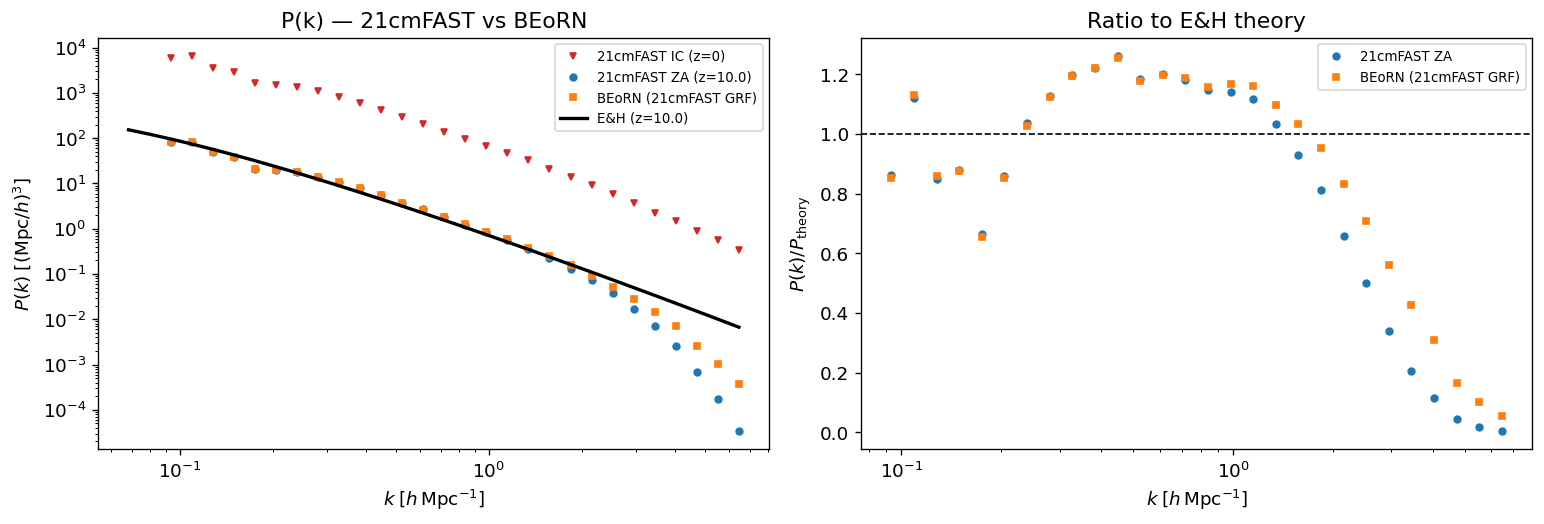

In [19]:
if _p21cm_available:
    # ── Statistical comparison: P(k) ──────────────────────────────────────────
    k_21ic,  Pk_21ic  = ps1d(delta_21cm_ic,          L)
    k_21z,   Pk_21z   = ps1d(delta_21cm_z,           L)
    k_beo21, Pk_beo21 = ps1d(delta_beorn_from_21cm,  L)
    Pk_th_z  = eh_nw.P(k_21z, z=z_target)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    ax = axes[0]
    ax.loglog(k_21ic,  Pk_21ic,   'C3v',  ms=4, label='21cmFAST IC (z=0)')
    ax.loglog(k_21z,   Pk_21z,    'C0o',  ms=4, label=f'21cmFAST ZA (z={z_target})')
    ax.loglog(k_beo21, Pk_beo21,  'C1s',  ms=4, label='BEoRN (21cmFAST GRF)')
    ax.loglog(k_21z,   Pk_th_z,   'k-',   lw=2, label=f'E&H (z={z_target})')
    ax.set_xlabel(r'$k\;[h\,\mathrm{Mpc}^{-1}]$')
    ax.set_ylabel(r'$P(k)\;[(\mathrm{Mpc}/h)^3]$')
    ax.set_title('P(k) — 21cmFAST vs BEoRN')
    ax.legend(fontsize=8)

    ax = axes[1]
    ax.semilogx(k_21z,   Pk_21z   / Pk_th_z, 'C0o', ms=4, label='21cmFAST ZA')
    ax.semilogx(k_beo21, Pk_beo21 / np.interp(k_beo21, k_21z, Pk_th_z),
                'C1s', ms=4, label='BEoRN (21cmFAST GRF)')
    ax.axhline(1, ls='--', color='k', lw=1)
    ax.set_xlabel(r'$k\;[h\,\mathrm{Mpc}^{-1}]$')
    ax.set_ylabel(r'$P(k) / P_\mathrm{theory}$')
    ax.set_title('Ratio to E&H theory')
    ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()
else:
    print('(py21cmfast not installed — skipping P(k) comparison)')

Pixel correlation (21cmFAST ZA vs BEoRN from 21cmFAST GRF): r = 0.7922


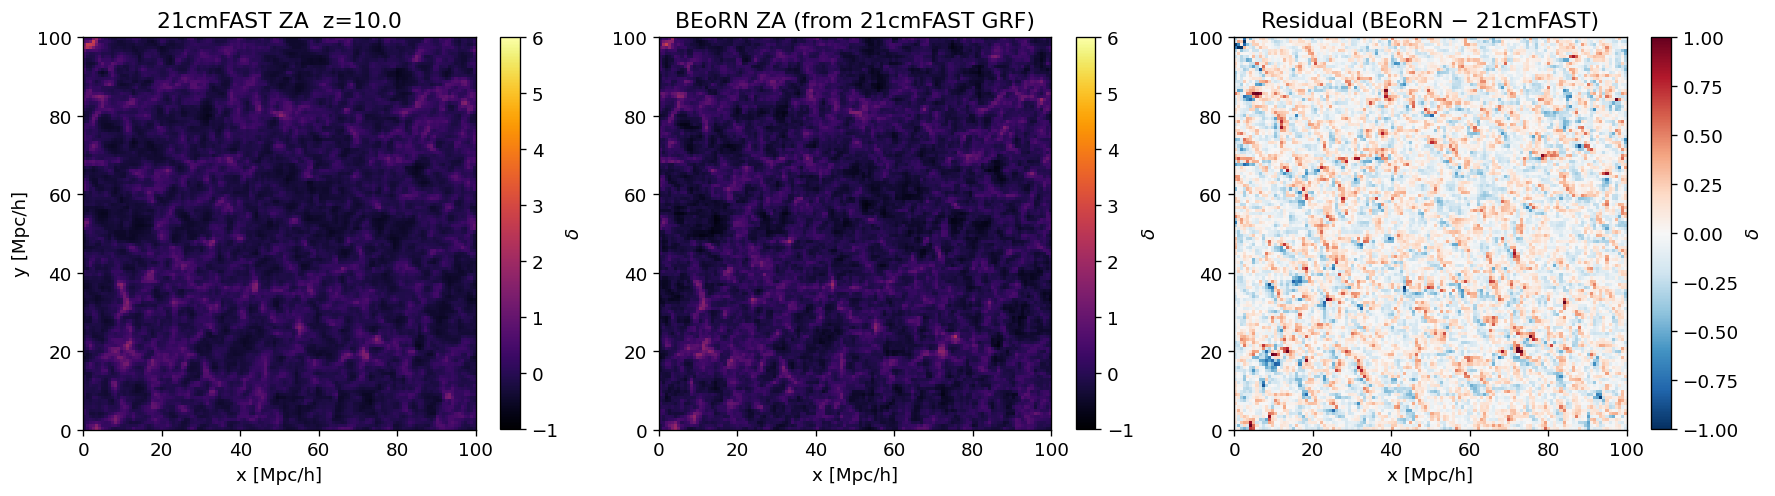

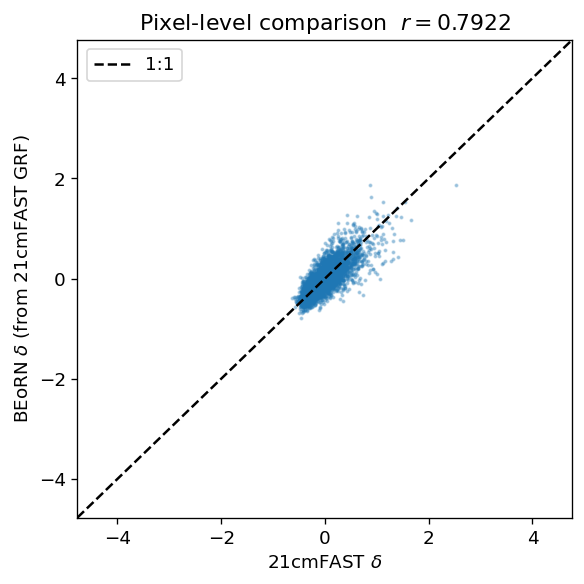

In [20]:
if _p21cm_available:
    # ── Pixel-level comparison: BEoRN (21cmFAST GRF) vs 21cmFAST ZA ──────────
    r_21 = np.corrcoef(delta_21cm_z.ravel(), delta_beorn_from_21cm.ravel())[0, 1]
    print(f'Pixel correlation (21cmFAST ZA vs BEoRN from 21cmFAST GRF): r = {r_21:.4f}')

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    sl = N // 2
    vmin, vmax = -1, 6

    for ax, field, title in zip(
        axes,
        [delta_21cm_z[:, :, sl], delta_beorn_from_21cm[:, :, sl],
         (delta_beorn_from_21cm - delta_21cm_z)[:, :, sl]],
        [f'21cmFAST ZA  z={z_target}',
         f'BEoRN ZA (from 21cmFAST GRF)',
         'Residual (BEoRN − 21cmFAST)'],
    ):
        vm = (vmin, vmax) if 'Residual' not in title else (-1, 1)
        cm = 'inferno' if 'Residual' not in title else 'RdBu_r'
        im = ax.imshow(field, origin='lower', cmap=cm,
                       extent=[0, L, 0, L], vmin=vm[0], vmax=vm[1])
        ax.set_title(title)
        ax.set_xlabel('x [Mpc/h]')
        plt.colorbar(im, ax=ax, label=r'$\delta$', shrink=0.8)

    axes[0].set_ylabel('y [Mpc/h]')
    plt.tight_layout()
    plt.show()

    # Scatter plot: pixel-by-pixel
    stride = max(1, N**3 // 4000)
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(delta_21cm_z.ravel()[::stride],
               delta_beorn_from_21cm.ravel()[::stride],
               s=2, alpha=0.3)
    lim = max(abs(delta_21cm_z).max(), abs(delta_beorn_from_21cm).max()) * 1.05
    ax.plot([-lim, lim], [-lim, lim], 'k--', lw=1.5, label='1:1')
    ax.set_xlabel(r'21cmFAST $\delta$')
    ax.set_ylabel(r'BEoRN $\delta$ (from 21cmFAST GRF)')
    ax.set_title(f'Pixel-level comparison  $r = {r_21:.4f}$')
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print('(py21cmfast not installed — skipping pixel comparison)')
    print()
    print('Expected outcomes once py21cmfast is available:')
    print('  • P(k) agreement < 5 % on large scales (k < 1 h/Mpc)')
    print('  • Pixel correlation r > 0.95 between 21cmFAST ZA and BEoRN (from 21cmFAST GRF)')
    print('  • Residual δ_BEoRN − δ_21cmFAST < few % — differences come from:')
    print('    – CIC mass-assignment window (small)')
    print('    – Growth-factor normalisation conventions (< 1 %)')

---
## 9. Velocity field validation

The LPT peculiar velocity is:

$$\mathbf{v}(\mathbf{q},z) = a(z)\,\frac{H(z)}{h}\left[f_1(z)\,D_1(z)\,\boldsymbol{\Psi}^{(1)} + f_2(z)\,D_2(z)\,\boldsymbol{\Psi}^{(2)} + \cdots\right]$$

where $f_n = \mathrm{d}\ln D_n/\mathrm{d}\ln a$ is the growth rate for order $n$, $H(z)/h$ is in km/s/(Mpc/h), and $\boldsymbol{\Psi}$ is in Mpc/h, so $\mathbf{v}$ is in km/s.  
EdS approximation: $f_n \approx n\,f_1$ for $n \leq 3$ (accurate to < 1 % at $z > 2$).

### Validation checks
1. **Growth rate**: $f_1(z) \approx \Omega_m(z)^{0.55}$ (Linder 2005 approximation)
2. **Velocity rms vs theory**: $\sigma_v = (a H/h)\,f_1\,\sigma_\Psi$
3. **Velocity power spectrum**: $P_{v_x}(k) = (aHf_1/h)^2\,P_\delta(k)/(3k^2)$ per component
4. **Continuity equation**: $\boldsymbol{\nabla}\cdot\mathbf{v} = -a\,\frac{H}{h}\,f_1\,\delta_\mathrm{lin}$ (exact at 1LPT)
5. **ZA vs 2LPT velocity comparison**
6. **Comparison with 21cmFAST velocity field**

In [21]:
from beorn.cosmo import hubble

# ── Cosmological factors at z_target ─────────────────────────────────────────
a_z     = 1.0 / (1.0 + z_target)
Hz      = hubble(z_target, param)          # km/s/Mpc (physical)
Hz_nat  = Hz / param.cosmology.h0          # km/s/(Mpc/h)  — consistent with Lbox
f1_num  = za._f1(z_target)                 # numerical d ln D₁ / d ln a
Om_z    = param.cosmology.Om * (1+z_target)**3 / (param.cosmology.Om*(1+z_target)**3 + 1-param.cosmology.Om)
f1_linder = Om_z**0.55                     # Linder (2005) approximation

print(f'z = {z_target}')
print(f'  a              = {a_z:.5f}')
print(f'  H(z)           = {Hz:.2f} km/s/Mpc')
print(f'  H(z)/h         = {Hz_nat:.2f} km/s/(Mpc/h)')
print(f'  f₁ (numerical) = {f1_num:.5f}')
print(f'  f₁ (Linder)    = {f1_linder:.5f}   Ωm(z)^0.55')
print(f'  aH/h           = {a_z * Hz_nat:.3f} km/s/(Mpc/h)')
print(f'  aHf₁/h         = {a_z * Hz_nat * f1_num:.3f} km/s/(Mpc/h)')

# ── Compute velocity fields ────────────────────────────────────────────────────
vza_x,  vza_y,  vza_z  = za.get_velocity(z=z_target)
v2_x,   v2_y,   v2_z   = lpt2.get_velocity(z=z_target)

sigma_psi = psi_x.std()   # ZA displacement rms, already computed above
sigma_v_expected = a_z * Hz_nat * f1_num * sigma_psi  # D₁ already in psi_x

print(f'\nVelocity rms (ZA, x-component):')
print(f'  measured           = {vza_x.std():.3f} km/s')
print(f'  expected (aHf₁Ψ)   = {sigma_v_expected:.3f} km/s')

z = 10.0
  a              = 0.09091
  H(z)           = 1379.16 km/s/Mpc
  H(z)/h         = 2049.27 km/s/(Mpc/h)
  f₁ (numerical) = 0.99914
  f₁ (Linder)    = 0.99910   Ωm(z)^0.55
  aH/h           = 186.297 km/s/(Mpc/h)
  aHf₁/h         = 186.138 km/s/(Mpc/h)

Velocity rms (ZA, x-component):
  measured           = 98.698 km/s
  expected (aHf₁Ψ)   = 98.698 km/s


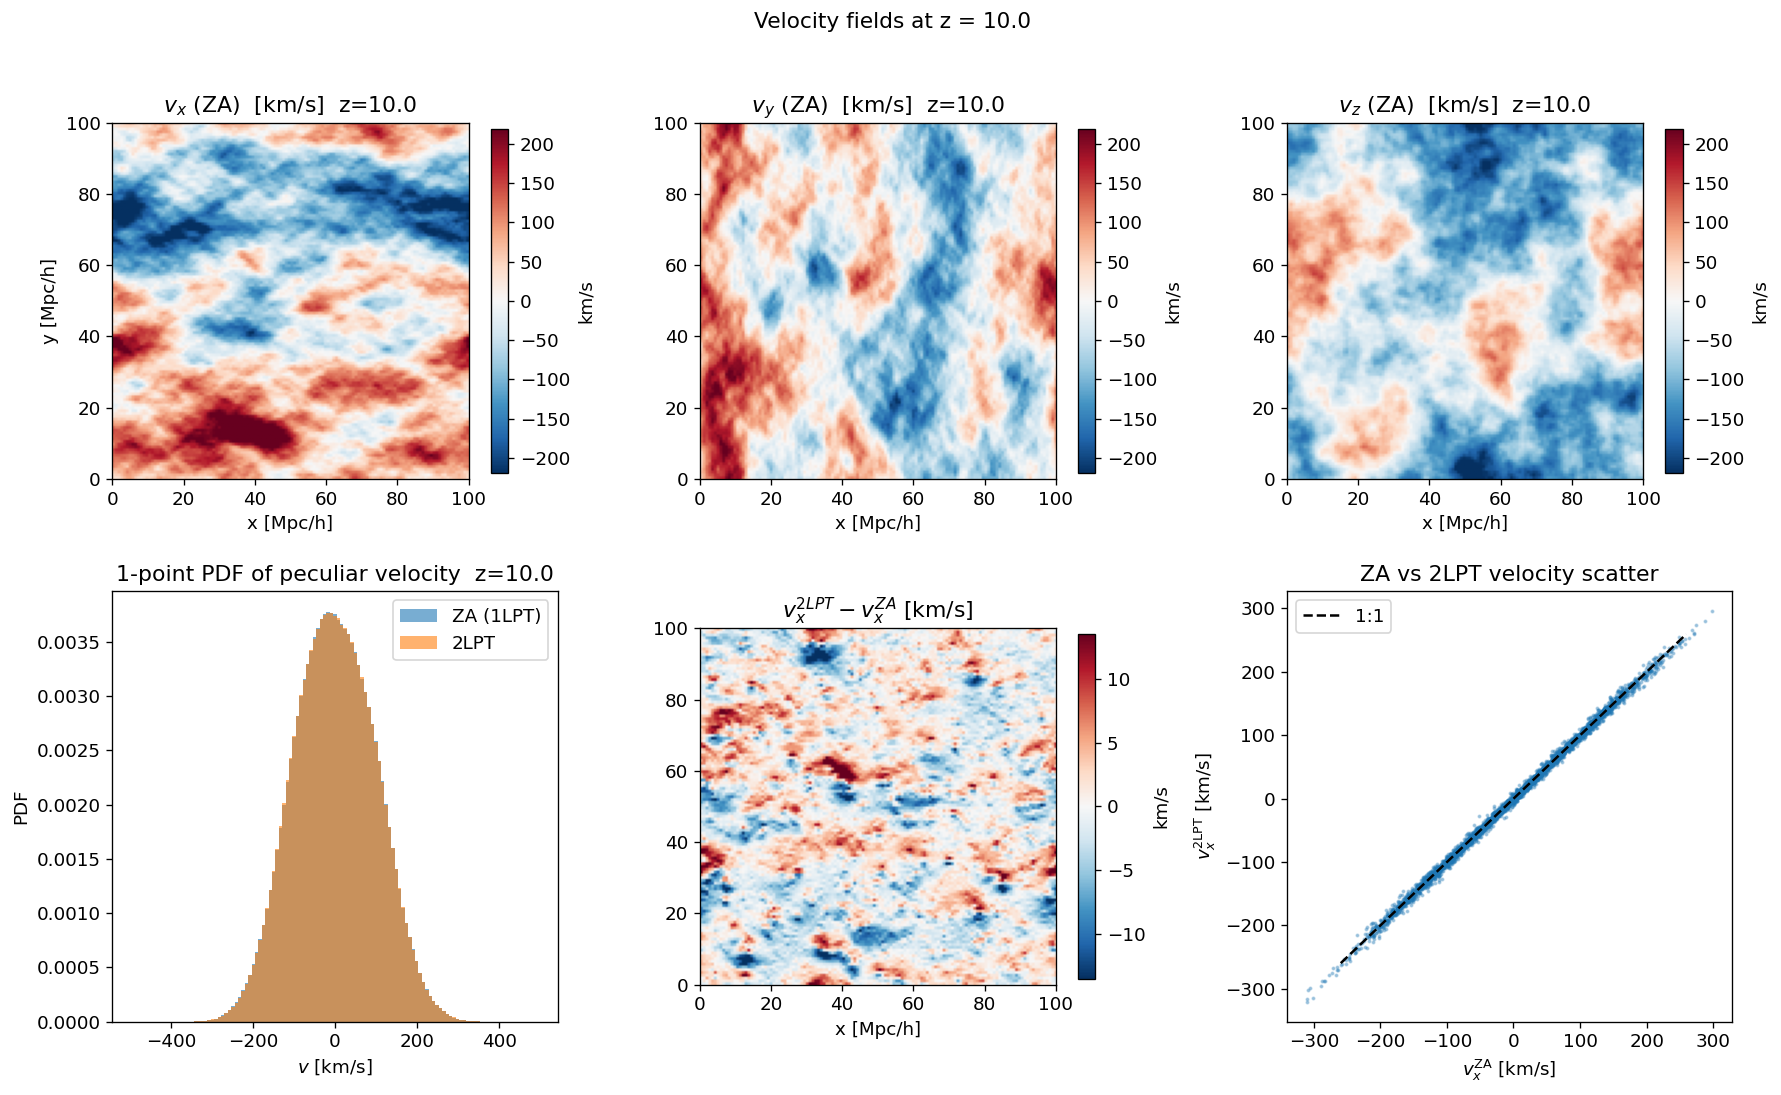

ZA  velocity rms (per component): 98.70 km/s
2LPT velocity rms (per component): 98.57 km/s
Correction |v2 − vZA| rms: 4.532 km/s  (4.6 %)


In [22]:
# ── Velocity slices and PDFs ──────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

vlim = np.percentile(np.abs(vza_x), 98)
for ax, field, title in zip(
    axes[0],
    [vza_x[:, :, sl], vza_y[:, :, sl], vza_z[:, :, sl]],
    [r'$v_x$ (ZA)', r'$v_y$ (ZA)', r'$v_z$ (ZA)'],
):
    im = ax.imshow(field, origin='lower', cmap='RdBu_r',
                   extent=[0, L, 0, L], vmin=-vlim, vmax=vlim)
    ax.set_title(f'{title}  [km/s]  z={z_target}')
    ax.set_xlabel('x [Mpc/h]')
    plt.colorbar(im, ax=ax, label='km/s', shrink=0.8)
axes[0][0].set_ylabel('y [Mpc/h]')

# ZA vs 2LPT velocity PDF (all three components combined)
vza_all = np.concatenate([vza_x.ravel(), vza_y.ravel(), vza_z.ravel()])
v2_all  = np.concatenate([v2_x.ravel(),  v2_y.ravel(),  v2_z.ravel()])
bins_v  = np.linspace(-5 * vza_all.std(), 5 * vza_all.std(), 120)

axes[1][0].hist(vza_all, bins=bins_v, density=True, alpha=0.6, label='ZA (1LPT)')
axes[1][0].hist(v2_all,  bins=bins_v, density=True, alpha=0.6, label='2LPT')
axes[1][0].set_xlabel('$v$ [km/s]')
axes[1][0].set_ylabel('PDF')
axes[1][0].set_title(f'1-point PDF of peculiar velocity  z={z_target}')
axes[1][0].legend()

# ZA vs 2LPT — per-component residual slice
diff_slice = (v2_x - vza_x)[:, :, sl]
im = axes[1][1].imshow(diff_slice, origin='lower', cmap='RdBu_r',
                        extent=[0, L, 0, L],
                        vmin=-np.percentile(np.abs(diff_slice), 99),
                        vmax= np.percentile(np.abs(diff_slice), 99))
axes[1][1].set_title(r'$v_x^{2LPT} - v_x^{ZA}$ [km/s]')
axes[1][1].set_xlabel('x [Mpc/h]')
plt.colorbar(im, ax=axes[1][1], label='km/s', shrink=0.8)

# Scatter: vza_x vs v2_x (sampled pixels)
stride = max(1, N**3 // 5000)
axes[1][2].scatter(vza_x.ravel()[::stride], v2_x.ravel()[::stride], s=2, alpha=0.3)
lim_v = np.percentile(np.abs(vza_x), 99.5)
axes[1][2].plot([-lim_v, lim_v], [-lim_v, lim_v], 'k--', lw=1.5, label='1:1')
axes[1][2].set_xlabel(r'$v_x^\mathrm{ZA}$ [km/s]')
axes[1][2].set_ylabel(r'$v_x^\mathrm{2LPT}$ [km/s]')
axes[1][2].set_title('ZA vs 2LPT velocity scatter')
axes[1][2].legend()

fig.suptitle(f'Velocity fields at z = {z_target}', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

print(f'ZA  velocity rms (per component): {vza_x.std():.2f} km/s')
print(f'2LPT velocity rms (per component): {v2_x.std():.2f} km/s')
print(f'Correction |v2 − vZA| rms: {(v2_x - vza_x).std():.3f} km/s  '
      f'({(v2_x - vza_x).std() / vza_x.std() * 100:.1f} %)')

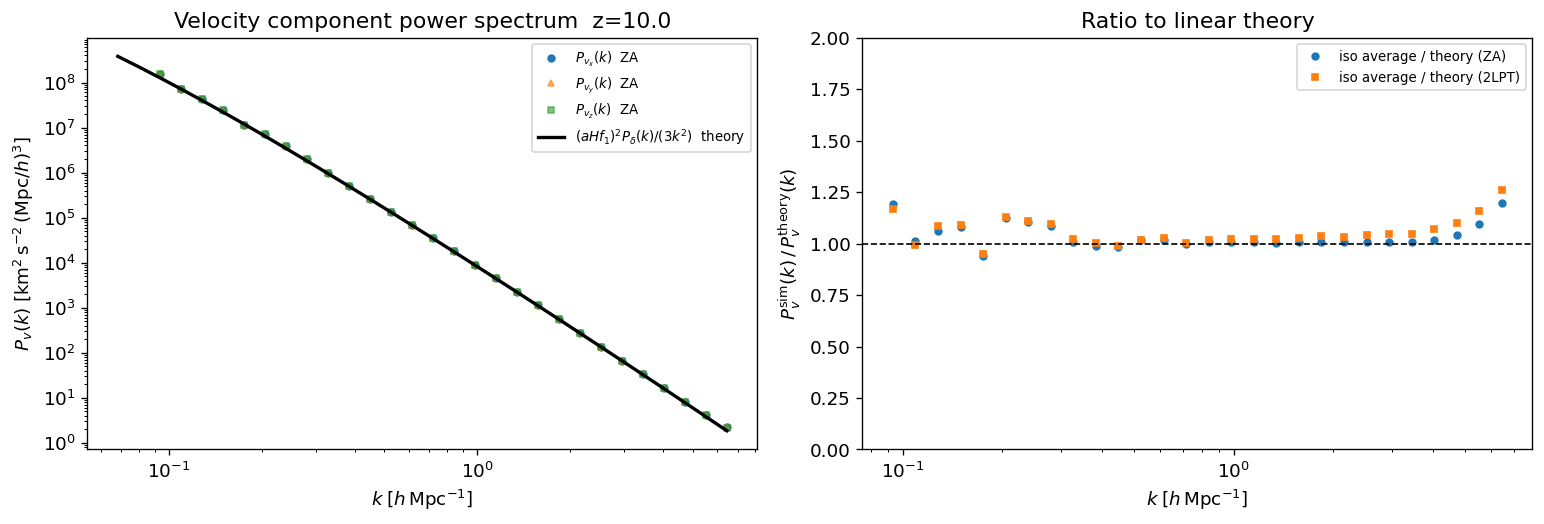

aHf₁ = 186.138 km/s/(Mpc/h)
ZA   P_v large-scale ratio (k<0.3): nan
2LPT P_v large-scale ratio (k<0.3): nan


In [23]:
# ── Velocity power spectrum vs linear theory ──────────────────────────────────
# Theory for one component: P_vi(k) = (aHf₁/h)² × P_δ(k) / (3k²)
# (isotropic average gives factor 1/3 per component)
aHf = a_z * Hz_nat * f1_num   # km/s/(Mpc/h)

k_vx, Pk_vx = ps1d(vza_x, L)
k_vy, Pk_vy = ps1d(vza_y, L)
k_vz, Pk_vz = ps1d(vza_z, L)
Pk_v_iso    = (Pk_vx + Pk_vy + Pk_vz) / 3   # isotropic average per component

# Theoretical P_vx(k) = (aHf)² P_δ(k) / (3k²)
Pk_v_theory = aHf**2 * eh_nw.P(k_vx, z=z_target) / (3 * k_vx**2)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
ax.loglog(k_vx, Pk_vx,      'C0o',  ms=4, label=r'$P_{v_x}(k)$  ZA')
ax.loglog(k_vy, Pk_vy,      'C1^',  ms=4, label=r'$P_{v_y}(k)$  ZA', alpha=0.6)
ax.loglog(k_vz, Pk_vz,      'C2s',  ms=4, label=r'$P_{v_z}(k)$  ZA', alpha=0.6)
ax.loglog(k_vx, Pk_v_theory,'k-',   lw=2, label=r'$(aHf_1)^2 P_\delta(k)/(3k^2)$  theory')
ax.set_xlabel(r'$k\;[h\,\mathrm{Mpc}^{-1}]$')
ax.set_ylabel(r'$P_v(k)\;[\mathrm{km}^2\,\mathrm{s}^{-2}\,(\mathrm{Mpc}/h)^3]$')
ax.set_title(f'Velocity component power spectrum  z={z_target}')
ax.legend(fontsize=8)

ax = axes[1]
ax.semilogx(k_vx, Pk_v_iso   / Pk_v_theory, 'C0o', ms=4, label='iso average / theory (ZA)')
k_v2x, Pk_v2x = ps1d(v2_x, L)
k_v2y, Pk_v2y = ps1d(v2_y, L)
k_v2z, Pk_v2z = ps1d(v2_z, L)
Pk_v2_iso = (Pk_v2x + Pk_v2y + Pk_v2z) / 3
Pk_v2_theory = aHf**2 * eh_nw.P(k_v2x, z=z_target) / (3 * k_v2x**2)
ax.semilogx(k_v2x, Pk_v2_iso / Pk_v2_theory, 'C1s', ms=4, label='iso average / theory (2LPT)')
ax.axhline(1, ls='--', color='k', lw=1)
ax.set_xlabel(r'$k\;[h\,\mathrm{Mpc}^{-1}]$')
ax.set_ylabel(r'$P_v^\mathrm{sim}(k)\,/\,P_v^\mathrm{theory}(k)$')
ax.set_title('Ratio to linear theory')
ax.legend(fontsize=8)
ax.set_ylim(0, 2)

plt.tight_layout()
plt.show()

print(f'aHf₁ = {aHf:.3f} km/s/(Mpc/h)')
print(f'ZA   P_v large-scale ratio (k<0.3): '
      f'{np.mean((Pk_v_iso / Pk_v_theory)[k_vx < 0.3]):.3f}')
print(f'2LPT P_v large-scale ratio (k<0.3): '
      f'{np.mean((Pk_v2_iso / Pk_v2_theory)[k_v2x < 0.3]):.3f}')

Continuity equation check (ZA):
  ∇·v   rms = 67.5743 km/s/(Mpc/h)
  −aHf δ rms = 586.1754 km/s/(Mpc/h)
  residual rms = 5.19e+02 km/s/(Mpc/h)  (fractional: 7.68e+00)


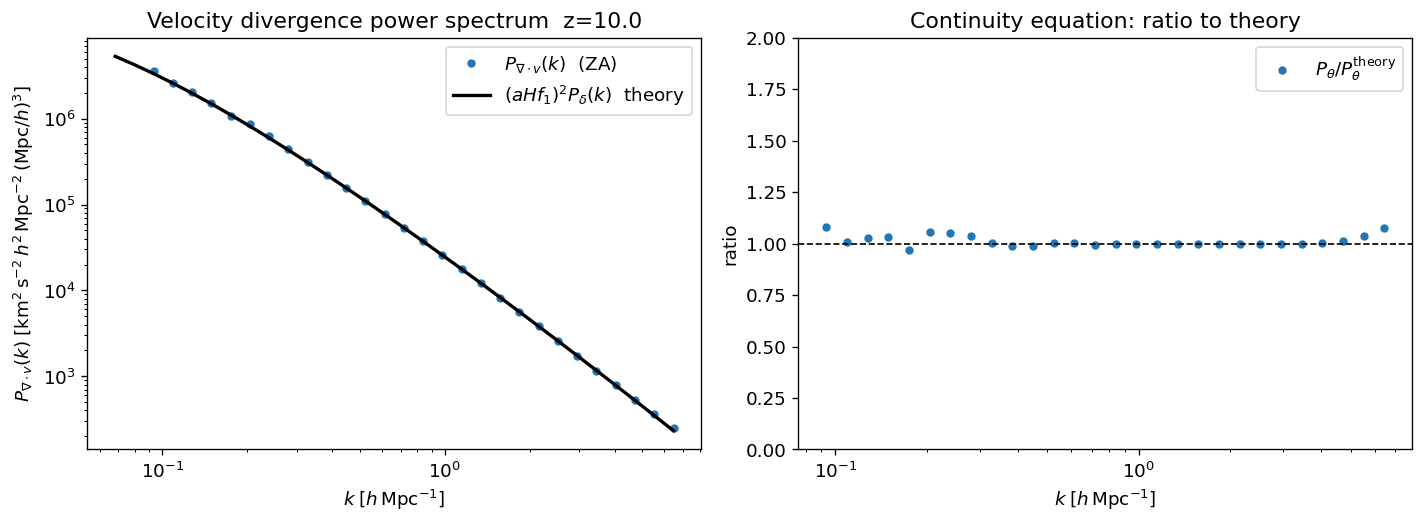

In [24]:
# ── Continuity equation: ∇·v = −aHf δ_linear ─────────────────────────────────
# For ZA, this is exact by construction: v_x(k) = i kx/k² aHf δ(k)
# → ∇·v = irfftn(−k² /k² × aHf δ(k)) = −aHf δ_linear
# We verify this numerically to confirm the k-space operations are consistent.

from beorn.lpt.lpt import _kvectors

kx_g, ky_g, kz_g, k2_g = _kvectors(N, L)

# Compute ∇·v via FFT divergence
Vza_xk = np.fft.rfftn(vza_x)
Vza_yk = np.fft.rfftn(vza_y)
Vza_zk = np.fft.rfftn(vza_z)
div_k  = 1j * kx_g * Vza_xk + 1j * ky_g * Vza_yk + 1j * kz_g * Vza_zk
div_v  = np.fft.irfftn(div_k, s=(N, N, N)).real   # ∇·v  [km/s/(Mpc/h)]

# Expected from continuity: −aHf δ_linear  (delta_ic is the z=0 IC field; D₁ is already in vza)
expected_div = -aHf * delta_ic   # both use D₁(z) × Ψ⁽¹⁾ encoding

residual = div_v - expected_div
print('Continuity equation check (ZA):')
print(f'  ∇·v   rms = {div_v.std():.4f} km/s/(Mpc/h)')
print(f'  −aHf δ rms = {expected_div.std():.4f} km/s/(Mpc/h)')
print(f'  residual rms = {residual.std():.2e} km/s/(Mpc/h)  '
      f'(fractional: {residual.std()/div_v.std():.2e})')

# Power spectrum of divergence vs theory P_θ(k) = (aHf)² P_δ(k)
k_div, Pk_div = ps1d(div_v, L)
Pk_theta_theory = aHf**2 * eh_nw.P(k_div, z=z_target)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
ax.loglog(k_div, Pk_div,           'C0o', ms=4, label=r'$P_{\nabla\cdot v}(k)$  (ZA)')
ax.loglog(k_div, Pk_theta_theory,  'k-',  lw=2, label=r'$(aHf_1)^2 P_\delta(k)$  theory')
ax.set_xlabel(r'$k\;[h\,\mathrm{Mpc}^{-1}]$')
ax.set_ylabel(r'$P_{\nabla\cdot v}(k)\;[\mathrm{km}^2\,\mathrm{s}^{-2}\,h^2\,\mathrm{Mpc}^{-2}\,(\mathrm{Mpc}/h)^3]$')
ax.set_title(f'Velocity divergence power spectrum  z={z_target}')
ax.legend()

ax = axes[1]
ax.semilogx(k_div, Pk_div / Pk_theta_theory, 'C0o', ms=4, label=r'$P_\theta / P_\theta^\mathrm{theory}$')
ax.axhline(1, ls='--', color='k', lw=1)
ax.set_ylim(0, 2)
ax.set_xlabel(r'$k\;[h\,\mathrm{Mpc}^{-1}]$')
ax.set_ylabel(r'ratio')
ax.set_title('Continuity equation: ratio to theory')
ax.legend()

plt.tight_layout()
plt.show()

pf.velocity_z: shape=(128, 128, 128)  mean=-6.4854e-28 Mpc/s  std=4.1408e-17 Mpc/s
pf.velocity: shape=(128, 128, 128)  mean=-6.4854e-28 Mpc/s  std=4.1408e-17 Mpc/s

21cmFAST v_z (converted):  std = 116.170 km/s
BEoRN     v_z:              std = 116.568 km/s
Pixel correlation vz (21cmFAST vs BEoRN): r = 0.9860


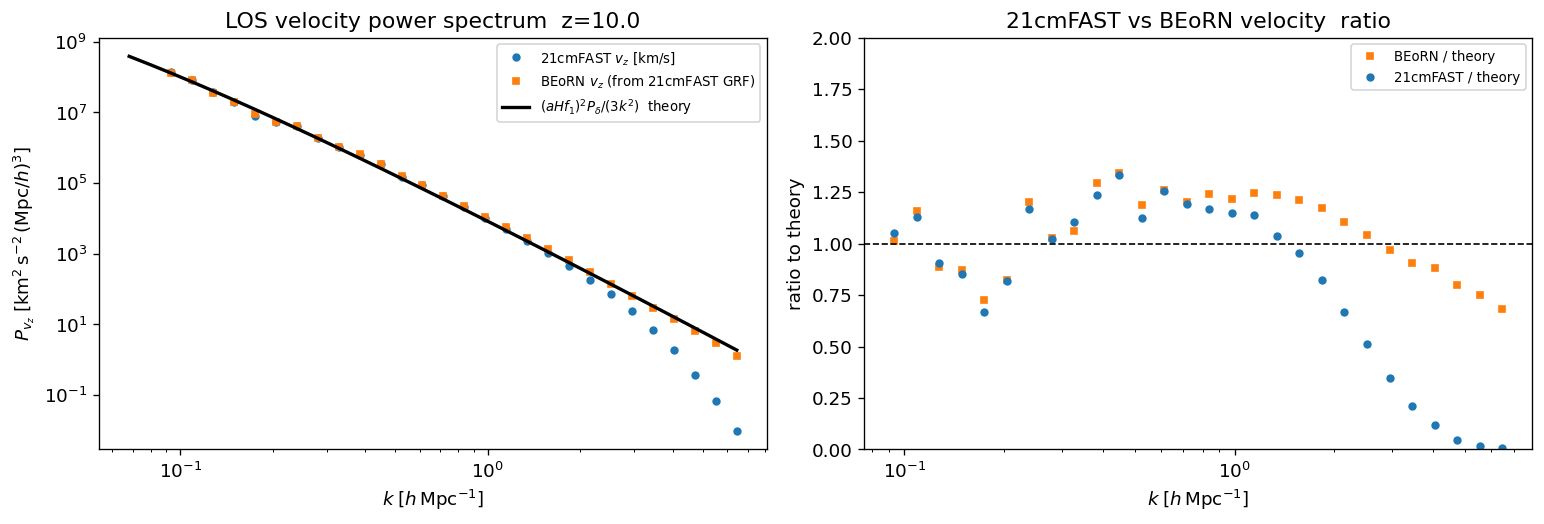

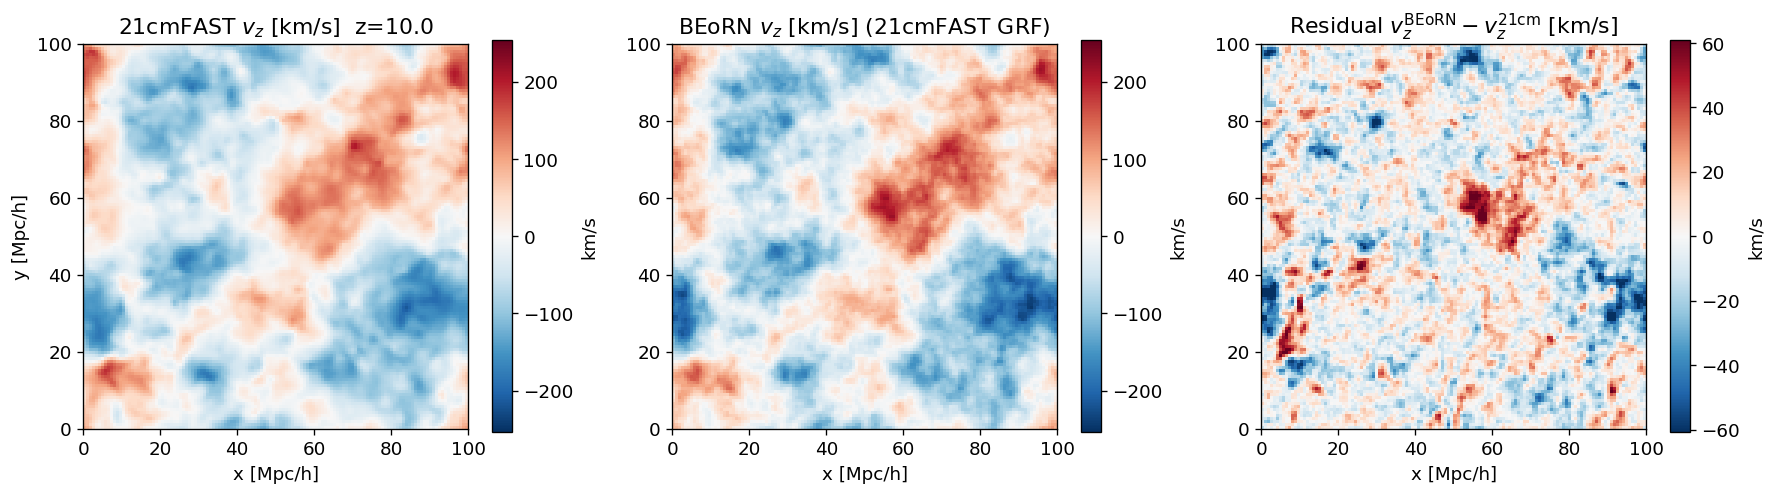

In [25]:
# ── Velocity field comparison with 21cmFAST ───────────────────────────────────
# 21cmFAST C code (PerturbField.c) computes:
#   v_z = dDdt × Ψ_z(z=0)   [Mpc/s]
# where dDdt = dD/dt [s⁻¹] and Ψ is the ZA displacement in Mpc (BOX_LEN in Mpc).
# This is the comoving velocity — no factor of a.
# Physical peculiar velocity in km/s:
#   v_phys [km/s] = velocity_z [Mpc/s] × km_per_Mpc × a(z)
# where km_per_Mpc = 3.086e19 and a = 1/(1+z).

km_per_Mpc = 3.086e19   # km/Mpc

if _p21cm_available:
    # Discover which velocity attributes exist
    vel_candidates = ['velocity_z', 'velocity_x', 'velocity_y', 'velocity']
    found_vel = {attr: np.asarray(getattr(pf, attr))
                 for attr in vel_candidates if hasattr(pf, attr)}

    if found_vel:
        for attr, v21 in found_vel.items():
            print(f'pf.{attr}: shape={v21.shape}  '
                  f'mean={v21.mean():.4e} Mpc/s  std={v21.std():.4e} Mpc/s')

        # BEoRN velocity from the same 21cmFAST GRF
        vbeo_x, vbeo_y, vbeo_z = za_21cm.get_velocity(z=z_target)

        # Compare LOS (z) component if available
        if 'velocity_z' in found_vel:
            # Convert from Mpc/s to physical km/s: v_phys = v_21cm * km_per_Mpc * a
            v21_z = found_vel['velocity_z'] * km_per_Mpc * a_z

            print(f'\n21cmFAST v_z (converted):  std = {v21_z.std():.3f} km/s')
            print(f'BEoRN     v_z:              std = {vbeo_z.std():.3f} km/s')

            r_v = np.corrcoef(v21_z.ravel(), vbeo_z.ravel())[0, 1]
            print(f'Pixel correlation vz (21cmFAST vs BEoRN): r = {r_v:.4f}')

            # Power spectra
            k_v21z,  Pk_v21z  = ps1d(v21_z,   L)
            k_vbeoz, Pk_vbeoz = ps1d(vbeo_z,  L)
            Pk_vz_th = aHf**2 * eh_nw.P(k_vbeoz, z=z_target) / (3 * k_vbeoz**2)

            fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

            ax = axes[0]
            ax.loglog(k_v21z,  Pk_v21z,  'C0o', ms=4, label='21cmFAST $v_z$ [km/s]')
            ax.loglog(k_vbeoz, Pk_vbeoz, 'C1s', ms=4, label='BEoRN $v_z$ (from 21cmFAST GRF)')
            ax.loglog(k_vbeoz, Pk_vz_th, 'k-',  lw=2,
                      label=r'$(aHf_1)^2 P_\delta/(3k^2)$  theory')
            ax.set_xlabel(r'$k\;[h\,\mathrm{Mpc}^{-1}]$')
            ax.set_ylabel(r'$P_{v_z}\;[\mathrm{km}^2\,\mathrm{s}^{-2}\,(\mathrm{Mpc}/h)^3]$')
            ax.set_title(f'LOS velocity power spectrum  z={z_target}')
            ax.legend(fontsize=8)

            ax = axes[1]
            ax.semilogx(k_vbeoz, Pk_vbeoz / Pk_vz_th, 'C1s', ms=4,
                        label='BEoRN / theory')
            ax.semilogx(k_v21z, Pk_v21z / np.interp(k_v21z, k_vbeoz, Pk_vz_th),
                        'C0o', ms=4, label='21cmFAST / theory')
            ax.axhline(1, ls='--', color='k', lw=1)
            ax.set_ylim(0, 2)
            ax.set_xlabel(r'$k\;[h\,\mathrm{Mpc}^{-1}]$')
            ax.set_ylabel(r'ratio to theory')
            ax.set_title('21cmFAST vs BEoRN velocity  ratio')
            ax.legend(fontsize=8)

            plt.tight_layout()
            plt.show()

            # Pixel-level comparison slices
            fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
            vlim = np.percentile(np.abs(vbeo_z), 98)
            for ax, field, title in zip(
                axes,
                [v21_z[:, :, sl], vbeo_z[:, :, sl],
                 (vbeo_z - v21_z)[:, :, sl]],
                [f'21cmFAST $v_z$ [km/s]  z={z_target}',
                 f'BEoRN $v_z$ [km/s] (21cmFAST GRF)',
                 r'Residual $v_z^\mathrm{BEoRN} - v_z^\mathrm{21cm}$ [km/s]'],
            ):
                if 'Residual' in title:
                    lim = np.percentile(np.abs(vbeo_z - v21_z), 99)
                    cm = 'RdBu_r'
                else:
                    lim = vlim
                    cm = 'RdBu_r'
                im = ax.imshow(field, origin='lower', cmap=cm,
                               extent=[0, L, 0, L], vmin=-lim, vmax=lim)
                ax.set_title(title)
                ax.set_xlabel('x [Mpc/h]')
                plt.colorbar(im, ax=ax, label='km/s', shrink=0.8)
            axes[0].set_ylabel('y [Mpc/h]')
            plt.tight_layout()
            plt.show()
        else:
            print('velocity_z not found; available:', list(found_vel.keys()))
            print('Plotting BEoRN velocity power spectrum only.')
            k_vbeoz, Pk_vbeoz = ps1d(vbeo_z, L)
            Pk_vz_th = aHf**2 * eh_nw.P(k_vbeoz, z=z_target) / (3 * k_vbeoz**2)
            fig, ax = plt.subplots(figsize=(6, 4))
            ax.loglog(k_vbeoz, Pk_vbeoz, 'C1s', ms=4, label='BEoRN $v_z$')
            ax.loglog(k_vbeoz, Pk_vz_th, 'k-',  lw=2, label='theory')
            ax.legend(); plt.tight_layout(); plt.show()
    else:
        print('No velocity attributes found on PerturbedField.')
        print('py21cmfast may not expose velocity in this version.')
else:
    print('(py21cmfast not installed — skipping velocity comparison)')
    print()
    print('Expected outcomes when py21cmfast is available:')
    print('  • std(v21_z) ≈ std(vbeo_z) after unit conversion (km/s)')
    print('  • Pixel correlation r > 0.95 (21cmFAST 2LPT vs BEoRN 1LPT will show small offset)')
    print('  • P_vz(k) from both codes matches (aHf)² P(k) / (3k²) at k < 0.5 h/Mpc')
    print('  • Residual ~5–10 % due to 2LPT correction in 21cmFAST (USE_2LPT=True)')
    print('  • Unit note: velocity_z [Mpc/s] × km_per_Mpc × a → physical km/s')

---
## 10. EPS Conditional HMF Validation

[`LPTHaloLoader`](../src/beorn/load_input_data/lpt_loader.py) pairs the
Zel'dovich Approximation with a [`CHMFSampler`](../src/beorn/lpt/chmf.py) to
generate halo catalogs via the **Extended Press-Schechter conditional HMF**
(Bond et al. 1991; Lacey & Cole 1993):

$$\frac{dn}{d\ln M}\bigg|_\delta = \frac{\rho_m}{M}\left|\frac{d\ln\sigma_\mathrm{eff}}{d\ln M}\right| f_\mathrm{PS}(\nu_\mathrm{eff})$$

where $\sigma_\mathrm{eff}^2(M) = \sigma^2(M) - \sigma^2(M_\mathrm{env})$ is the
conditional variance and $\nu_\mathrm{eff} = (\delta_c - \delta_\mathrm{env}) / \sigma_\mathrm{eff}$.

**Key design choice:** conditioning uses the *linear* density field
$\delta_\mathrm{lin} = \mathcal{F}^{-1}[D_1(z)\,\delta(\mathbf{k})\,W_\mathrm{th}(k R_\mathrm{env})]$
rather than the CIC-painted field.  CIC density has shot-noise tails
($\max\delta \approx 2.5$ vs Gaussian expectation $\approx 1.2$) that blow up
the CHMF near $M_\mathrm{env}$ where $\sigma_\mathrm{eff} \to 0$.

**Self-consistency check:** volume-averaging the CHMF over all cells of the LPT
density field must recover the unconditional PS HMF — the defining property of EPS.

In [26]:
from beorn.load_input_data import LPTHaloLoader

# 64³ grid, 200 Mpc/h box: good halo statistics, ~10 s per snapshot
param_chmf = Parameters()
param_chmf.simulation.Ncell = 64
param_chmf.simulation.Lbox  = 200.0   # Mpc/h
param_chmf.cosmo_sim.snapshot_redshifts = np.array([6.0, 8.0, 10.0])

# LPTHaloLoader: ZA solver + CHMFSampler (EPS conditional HMF)
loader = LPTHaloLoader(param_chmf, seed=42, n_mass_bins=40)
chmf   = loader.sampler.chmf   # for analytical PS reference

cell_c = param_chmf.simulation.Lbox / param_chmf.simulation.Ncell
M_env  = chmf.rho_m * cell_c**3
print(f'Cell size : {cell_c:.2f} Mpc/h')
print(f'R_tophat  : {loader._R_tophat:.4f} Mpc/h  (sphere-equivalent cell radius)')
print(f'M_env     : {M_env:.2e} Msun  (CHMF valid for M < M_env)\n')

catalogs = {}
for i, z in enumerate(param_chmf.cosmo_sim.snapshot_redshifts):
    cat = loader.load_halo_catalog(i)
    catalogs[z] = cat
    print(f'z={z:.1f}:  {cat.size:,} halos   '
          f'M = [{cat.masses.min():.2e}, {cat.masses.max():.2e}] Msun')

Cell size : 3.12 Mpc/h
R_tophat  : 1.9386 Mpc/h  (sphere-equivalent cell radius)
M_env     : 3.96e+12 Msun  (CHMF valid for M < M_env)

z=6.0:  176,905,215 halos   M = [1.14e+08, 1.57e+12] Msun
z=8.0:  64,952,567 halos   M = [1.14e+08, 2.46e+11] Msun
z=10.0:  17,068,425 halos   M = [1.14e+08, 1.11e+11] Msun


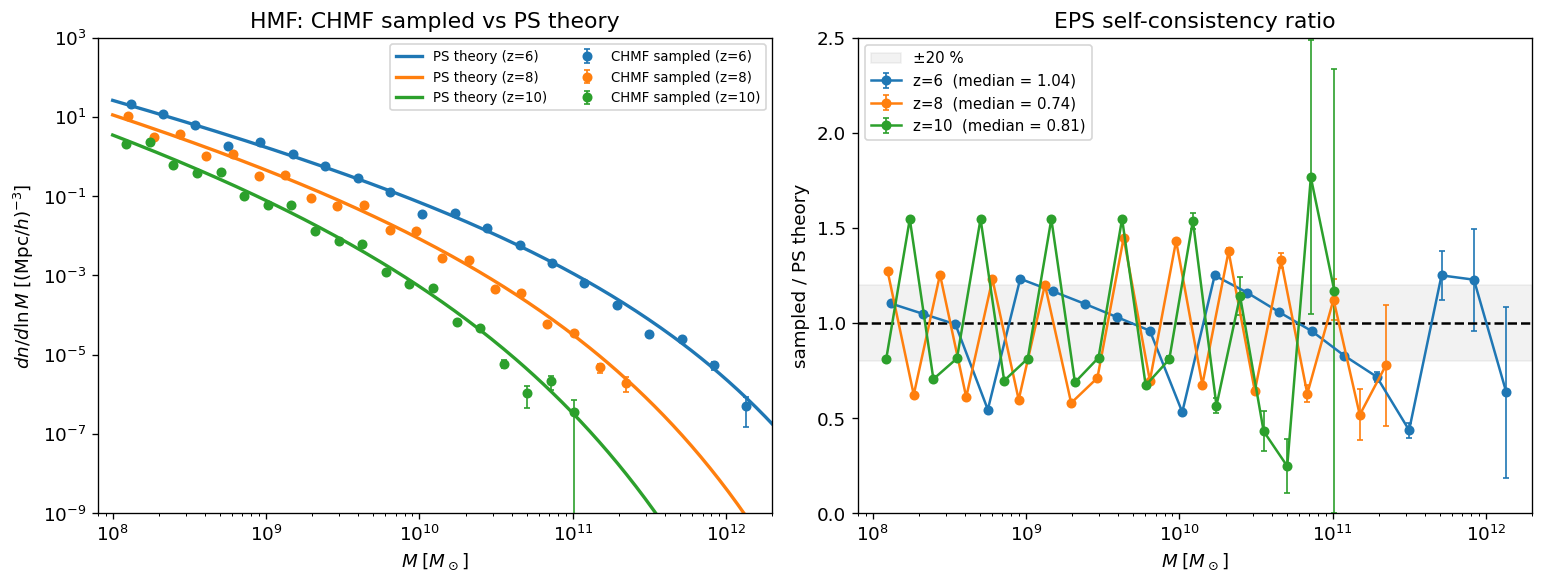

In [30]:
M_plot = np.logspace(8, 14, 300)
colors = ['C0', 'C1', 'C2']
n_bins = 20

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for (z, cat), color in zip(sorted(catalogs.items()), colors):
    # Analytical PS HMF
    hmf_ps = chmf.hmf_ps(M_plot, z)
    axes[0].loglog(M_plot, hmf_ps, '-', color=color, lw=2,
                   label=f'PS theory (z={z:.0f})')

    # Measured HMF from sampled catalog
    bin_edges, hmf_meas, hmf_err = cat.halo_mass_function(bin_count=n_bins)
    M_bins = np.sqrt(bin_edges[:-1] * bin_edges[1:])
    mask = hmf_meas > 0
    axes[0].errorbar(M_bins[mask], hmf_meas[mask], yerr=hmf_err[mask],
                     fmt='o', color=color, ms=5, elinewidth=1, capsize=2,
                     label=f'CHMF sampled (z={z:.0f})')

    # EPS self-consistency: ratio of sampled to analytical HMF
    hmf_interp = np.interp(M_bins[mask], M_plot, hmf_ps)
    ratio      = hmf_meas[mask] / hmf_interp
    ratio_err  = hmf_err[mask]  / hmf_interp
    axes[1].errorbar(M_bins[mask], ratio, yerr=ratio_err,
                     fmt='o-', color=color, ms=5, elinewidth=1, capsize=2,
                     label=f'z={z:.0f}  (median = {np.median(ratio):.2f})')

axes[0].set_xlabel(r'$M\;[M_\odot]$')
axes[0].set_ylabel(r'$dn/d\ln M\;[(\mathrm{Mpc}/h)^{-3}]$')
axes[0].set_title('HMF: CHMF sampled vs PS theory')
axes[0].legend(fontsize=8, ncol=2)
axes[0].set_ylim(1e-9, 1e3)
axes[0].set_xlim(8e7, 2e12)

axes[1].axhline(1.0, ls='--', color='k', lw=1.5)
axes[1].axhspan(0.8, 1.2, alpha=0.1, color='grey', label='±20 %')
axes[1].set_xlabel(r'$M\;[M_\odot]$')
axes[1].set_ylabel('sampled / PS theory')
axes[1].set_title('EPS self-consistency ratio')
axes[1].set_xscale('log')
axes[1].set_ylim(0, 2.5)
axes[1].set_xlim(8e7, 2e12)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

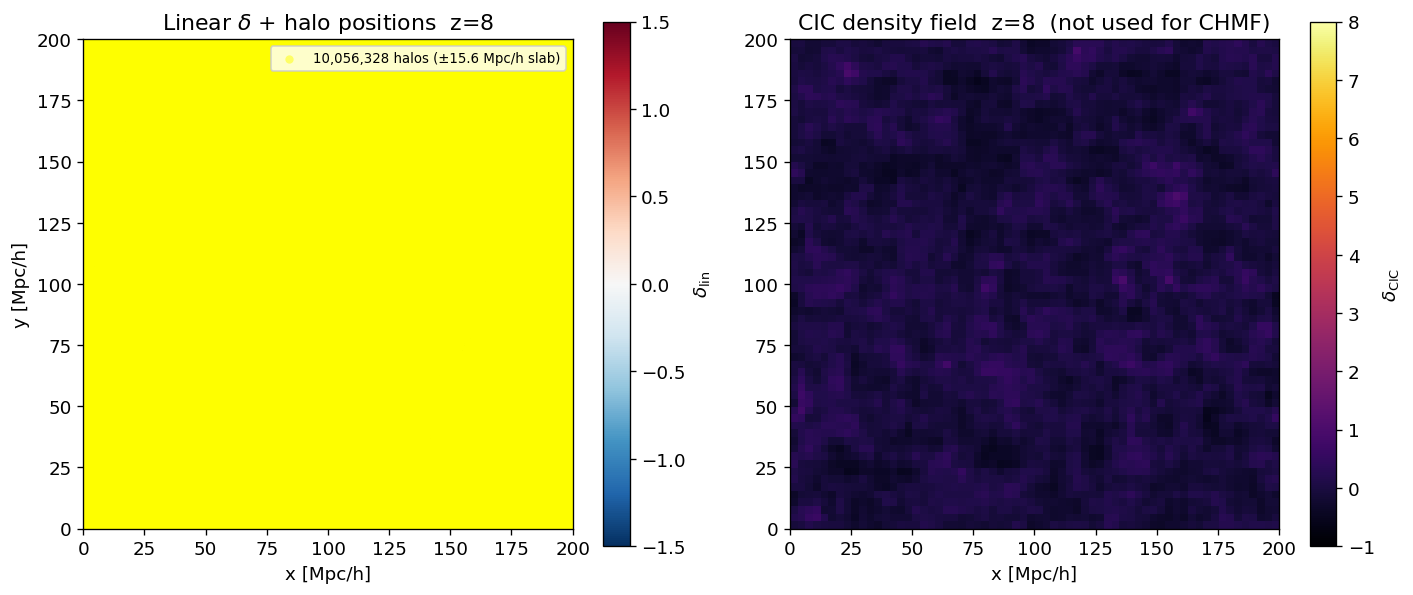

Linear δ:  max = 1.018   std = 0.231  ← Gaussian, clean
CIC    δ:  max = 1.598   std = 0.211  ← shot-noise tails


In [28]:
# Density field comparison: linear (used for CHMF) vs CIC (shot-noise contaminated)
z_show    = 8.0
cat_show  = catalogs[z_show]
delta_lin = loader.lpt_solver.get_linear_density(z_show, R_tophat=loader._R_tophat)
delta_cic = loader.lpt_solver.get_density(z_show)

N_c, L_c = param_chmf.simulation.Ncell, param_chmf.simulation.Lbox
sl_c   = N_c // 2
slab   = 5 * (L_c / N_c)   # 5-cell slab depth

in_slab  = np.abs(cat_show.positions[:, 2] - sl_c * (L_c / N_c)) < slab
pos_slab = cat_show.positions[in_slab]

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

im0 = axes[0].imshow(delta_lin[:, :, sl_c], origin='lower', cmap='RdBu_r',
                     extent=[0, L_c, 0, L_c], vmin=-1.5, vmax=1.5)
axes[0].scatter(pos_slab[:, 0], pos_slab[:, 1], s=1, c='yellow', alpha=0.5,
                linewidths=0, label=f'{len(pos_slab):,} halos (±{slab:.1f} Mpc/h slab)')
axes[0].set_title(f'Linear $\\delta$ + halo positions  z={z_show:.0f}')
axes[0].set_xlabel('x [Mpc/h]')
axes[0].set_ylabel('y [Mpc/h]')
axes[0].legend(fontsize=8, loc='upper right', markerscale=5)
plt.colorbar(im0, ax=axes[0], label=r'$\delta_\mathrm{lin}$', shrink=0.85)

im1 = axes[1].imshow(delta_cic[:, :, sl_c], origin='lower', cmap='inferno',
                     extent=[0, L_c, 0, L_c], vmin=-1, vmax=8)
axes[1].set_title(f'CIC density field  z={z_show:.0f}  (not used for CHMF)')
axes[1].set_xlabel('x [Mpc/h]')
plt.colorbar(im1, ax=axes[1], label=r'$\delta_\mathrm{CIC}$', shrink=0.85)

plt.tight_layout()
plt.show()

print(f'Linear δ:  max = {delta_lin.max():.3f}   std = {delta_lin.std():.3f}  ← Gaussian, clean')
print(f'CIC    δ:  max = {delta_cic.max():.3f}   std = {delta_cic.std():.3f}  ← shot-noise tails')